## Helper function

In [1]:
import datetime
def clean_datatime(value):
        if isinstance(value, datetime.datetime):          
            return value.month + value.day * 0.01
        elif isinstance(value, str):
            return float(value.replace('٫', '.'))
            #return float(value)
        else:
            return value
        
def clean_columns_datatime(data,numeric_target_columns):
    for column in numeric_target_columns:#['Seeds', 'Total Reward', 'Waiting', 'Speed','Depart Delay', 'Time Loss', 'Waiting Car', 'Total Time(m)']:
        if column in data.columns:
            data.loc[:, column] = data[column].apply(lambda x: clean_datatime(x))
    return data

def get_grouped_seed(data): # modified foe work with 4 seeds
    df = data.reset_index(drop=True)
    result_rows = []
    i = 0

    while i < len(df) - 3:  # now checking 4 rows at a time
        group = df.iloc[i:i+4]
        if set(group['Seed']) == {0, 1, 2, 3}:  # now checking for all 4 seeds
            # Average numeric columns
            numeric_cols = group.select_dtypes(include='number').columns
            avg_numeric = group[numeric_cols].mean()
            
            # Keep non-numeric columns from the first row
            non_numeric_cols = group.select_dtypes(exclude='number').columns
            non_numeric = group.iloc[0][non_numeric_cols]
            
            # Combine into a single averaged row
            new_row = pd.concat([non_numeric, avg_numeric])
            result_rows.append(new_row)
            
            i += 4  # Skip the group of 4 rows
        else:
            result_rows.append(df.iloc[i])  # Add this row as is
            i += 1

    # Add any remaining rows that were not part of a group
    while i < len(df):
        result_rows.append(df.iloc[i])
        i += 1

    # Create the final DataFrame
    result_df = pd.DataFrame(result_rows)

    return result_df





In [2]:
import plotly.graph_objects as go

def plot_spider_interactive(row, title):
    labels = row.index.tolist()
    values = row.values.flatten().tolist()
    values += values[:1]  # Close the loop
    labels += [labels[0]]

    fig = go.Figure()

    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=labels,
        fill='toself',
        name=title,
        hovertemplate="%{theta}: %{r:.2f}<extra></extra>"
    ))

    fig.update_layout(
        polar=dict(
            radialaxis=dict(visible=True)
        ),
        showlegend=False,
        title=title
    )

    fig.show()
    return fig


In [3]:
def clean_data(data_exp,numeric_target_columns):
    data_exp = clean_columns_datatime(data_exp,numeric_target_columns)
    data_exp['Depart Delay (s)'] = data_exp['Depart Delay (s)'].astype(float)
    data_exp['Speed (m/s)'] = data_exp['Speed (m/s)'].astype(float)
    data_exp['Total Time (M)'] = data_exp['Total Time (M)'].astype(float)
    data_exp[ 'Time Loss (s)'] = data_exp[ 'Time Loss (s)'].astype(float)
    data_exp['Waiting Car'] = data_exp['Waiting Car'].astype(int)
    data_exp['Waiting Time (s)'] = data_exp['Waiting Time (s)'].astype(float)
    data_exp['Reward of Last Episode'] = data_exp['Reward of Last Episode'].astype(float)
    data_exp['Average Reward for Evaluated Episodes'] = data_exp['Average Reward for Evaluated Episodes'].astype(float)
    data_exp['Derivative of Reward'] = data_exp['Derivative of Reward'].astype(float)
    data_exp['Seed'] = data_exp['Seed'].astype(int)
    data_exp['Traffic Scale'] = data_exp['Traffic Scale'].astype(float)
    return data_exp


## Load and Prepare 

In [4]:
import pandas as pd

data_exp = pd.read_excel('final_sheet_experiments.xlsx', sheet_name='Sheet1')



In [5]:
numeric_target_columns = ['Episodes', 'Max Sumo Steps(s)', 'Traffic Scale', 'Seed',
       'Reward of Last Episode', 'Average Reward for Evaluated Episodes',
       'Derivative of Reward', 'Waiting Time (s)', 'Speed (m/s)',
       'Depart Delay (s)', 'Time Loss (s)', 'Waiting Car', 'Total Time (M)']

## Analyzing features affect

#### Anayze Epsiodes Effect

In [6]:
data_exp_episode_effect = data_exp[data_exp['Study Group'].str.contains('Episode Effect;', na=False)]
data_exp_episode_effect

,Area,Reward,Environment Type,Algorithm,Episodes,Max Sumo Steps(s),Traffic Scale,Seed,Runned By,Reward of Last Episode,...,Derivative of Reward,Waiting Time (s),Speed (m/s),Depart Delay (s),Time Loss (s),Waiting Car,Total Time (M),Device,Notes,Study Group
547,Area2 (Mosheer Ismail),Proposed,HighGroupedSumoEnv,D3QN,200,2000,0٫38,0,Taha,-14.017,...,6.376,65.98,8.090,377.81,98.39,2376.0,13.269,colab,NaN,Episode Effect;
577,Area2 (Mosheer Ismail),Proposed,HighGroupedSumoEnv,D3QN,350,2000,0٫38,0,Ahmed,-13.4,...,6.994227010584536,63.44,8.13,394.56,95.38,2366.0,24.952,colab,NaN,Algorithm Performance; Episode Effect; Max Sum...
607,Area2 (Mosheer Ismail),Proposed,HighGroupedSumoEnv,D3QN,1000,2000,0٫38,0,Marwa,38.814,...,14.570218894089525,22.53,24.85,712.77,109.31,2272.0,98.193,i5,NaN,Episode Effect;
637,Area2 (Mosheer Ismail),Proposed,HighGroupedSumoEnv,PPO,200,2000,0٫38,0,Marwa,-21.520999908447266,...,0.5700283050537109,63.71,08.04,400.04,95.68,2361.0,7.142,i5,NaN,Episode Effect;
667,Area2 (Mosheer Ismail),Proposed,HighGroupedSumoEnv,PPO,350,2000,0٫38,0,Taha,-19.054,...,3.82,67.76,2025-08-19 00:00:00,392.3,100.6,2388.0,14.588,colab,deterministic = False,Algorithm Performance; Episode Effect; Max Sum...
697,Area2 (Mosheer Ismail),Proposed,HighGroupedSumoEnv,PPO,1000,2000,0٫38,0,Rimon,-18.913000106811523,...,7.263256072998047,63.86,7.96,397.56,96.26,2369.0,38.509,colab,NaN,Episode Effect;
1267,Area3 (San Stefano),Proposed,HighGroupedSumoEnv,D3QN,200,2000,0٫38,0,Youssef,28.264,...,4.020121283587404,23.94,24.81,714.94,111.96,2272.0,15.038,colab,NaN,Episode Effect;
1297,Area3 (San Stefano),Proposed,HighGroupedSumoEnv,D3QN,350,2000,0٫38,0,Taha,37.503,...,13.57,21.62,24.8,724.19,109.41,2277.0,46.181,colab,NaN,Algorithm Performance; Episode Effect; Max Sum...
1327,Area3 (San Stefano),Proposed,HighGroupedSumoEnv,D3QN,1000,2000,0٫38,0,Taha,30.867,...,6.62,23.8,25.72,713.26,109.77,2269.0,112.871,colab,NaN,Episode Effect;
1357,Area3 (San Stefano),Proposed,HighGroupedSumoEnv,PPO,200,2000,0٫38,0,Marwa,27.974000930786133,...,4.946964263916016,22.01,24.95,716.74,109.16,2272.0,7.305,i5,NaN,Episode Effect;


In [7]:
data_exp_episode_effect = clean_data(data_exp_episode_effect.copy(),numeric_target_columns)

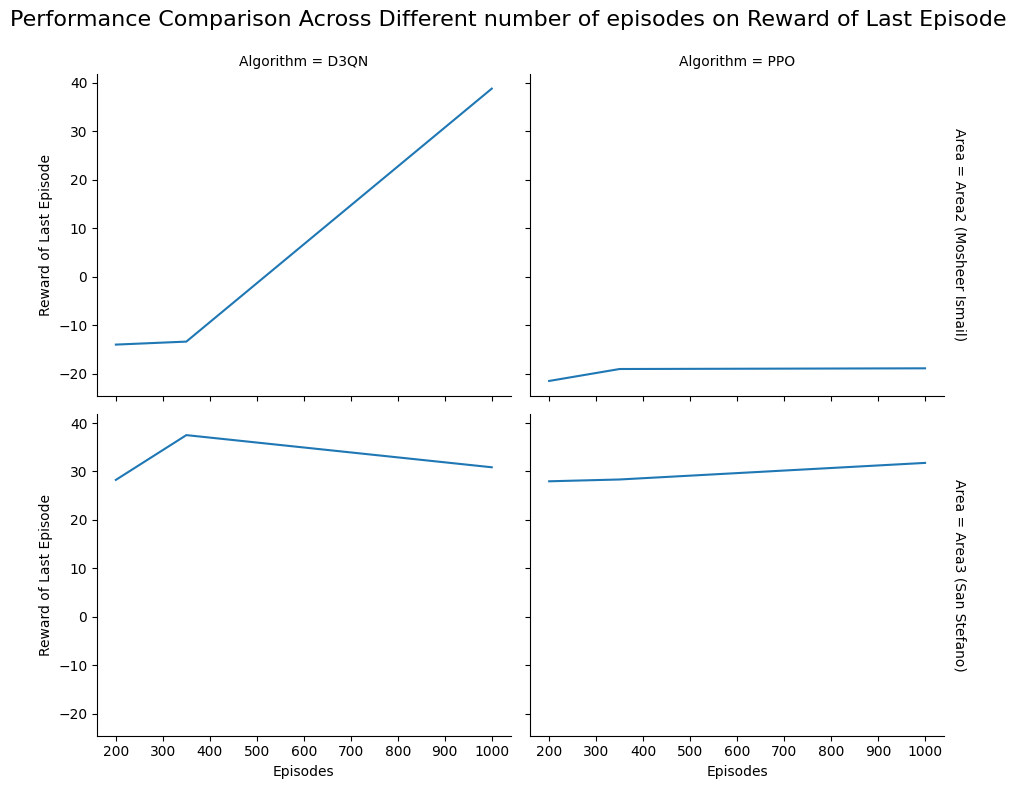

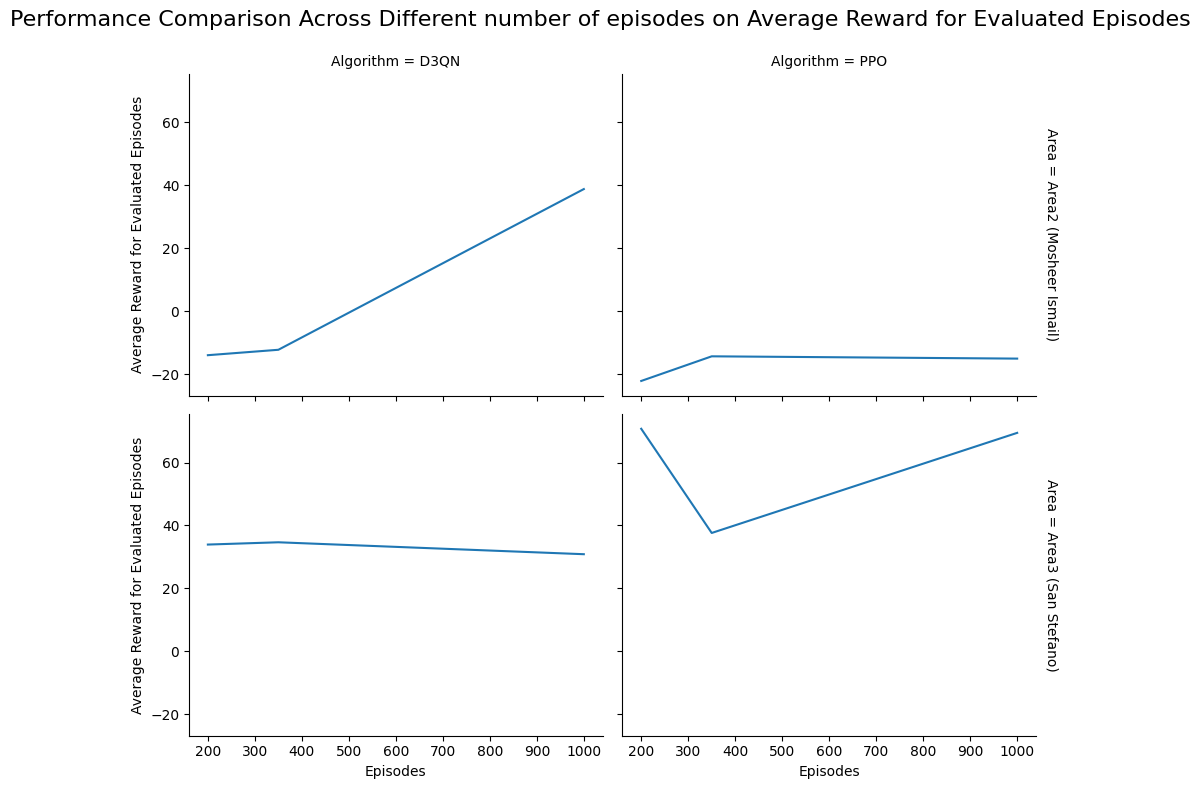

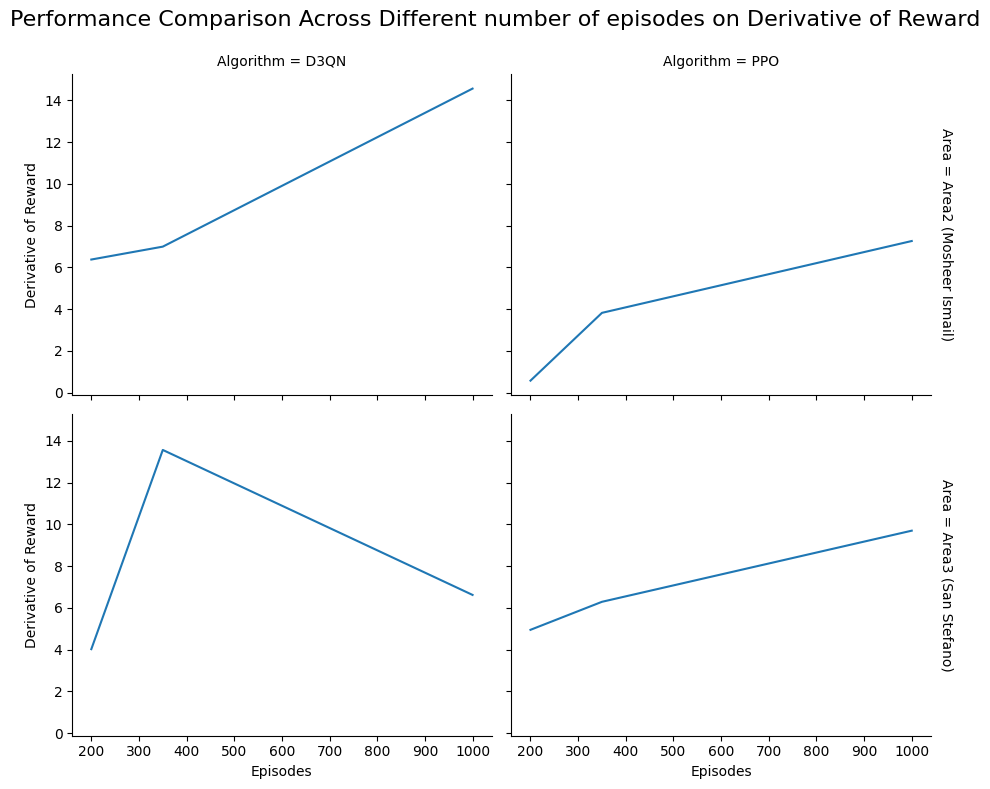

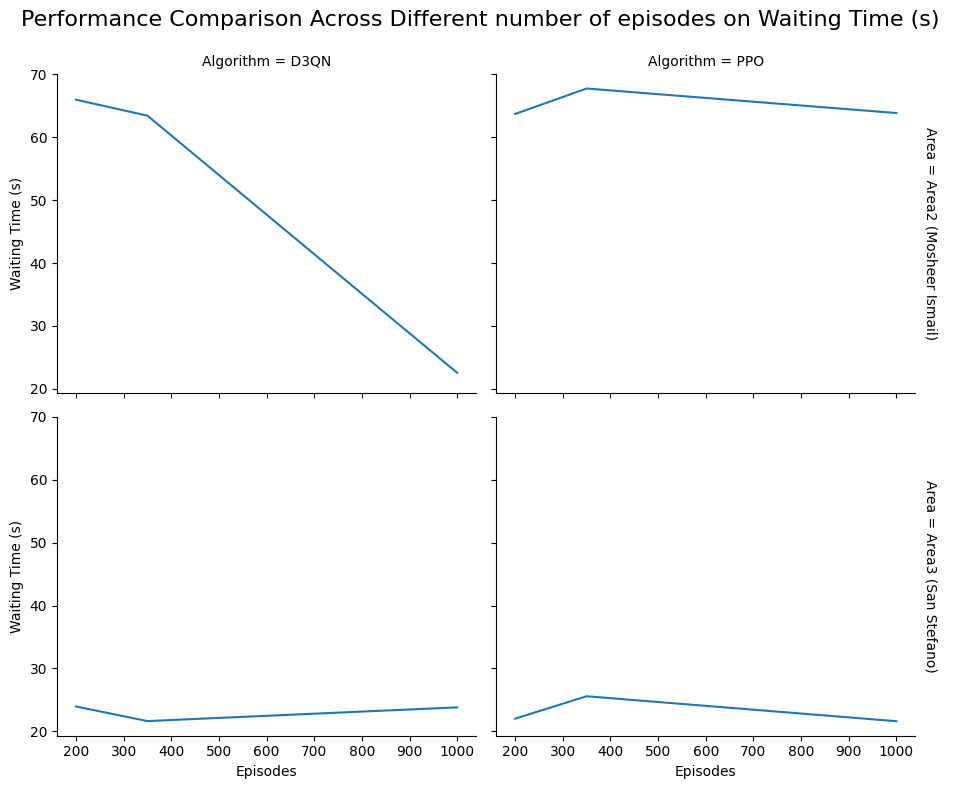

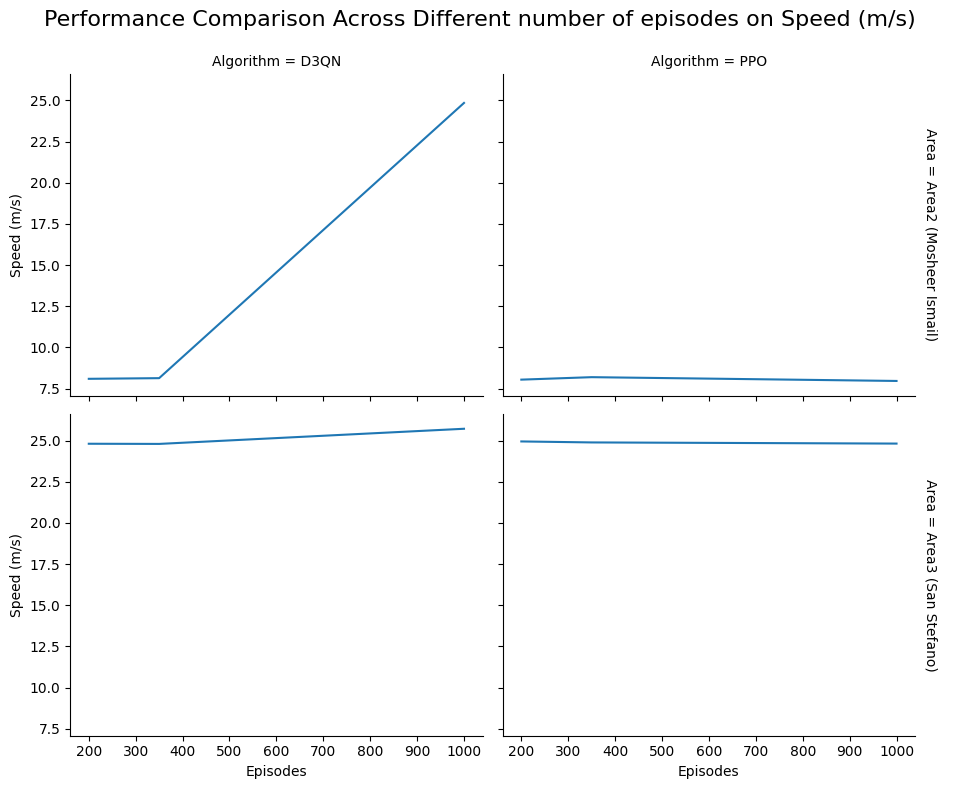

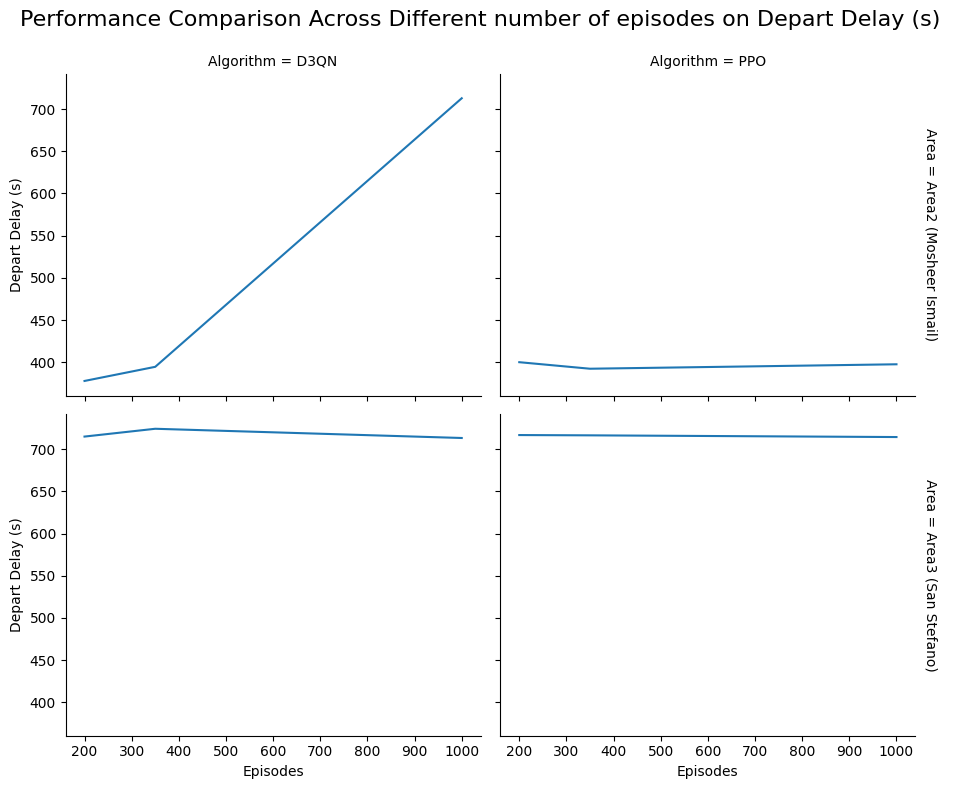

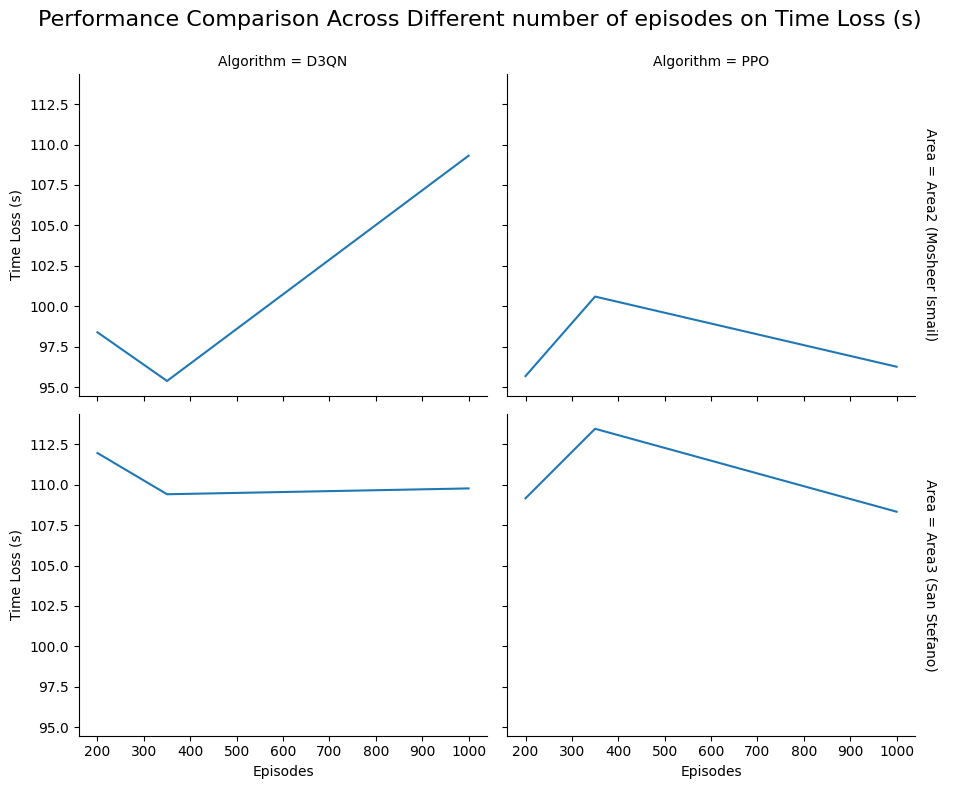

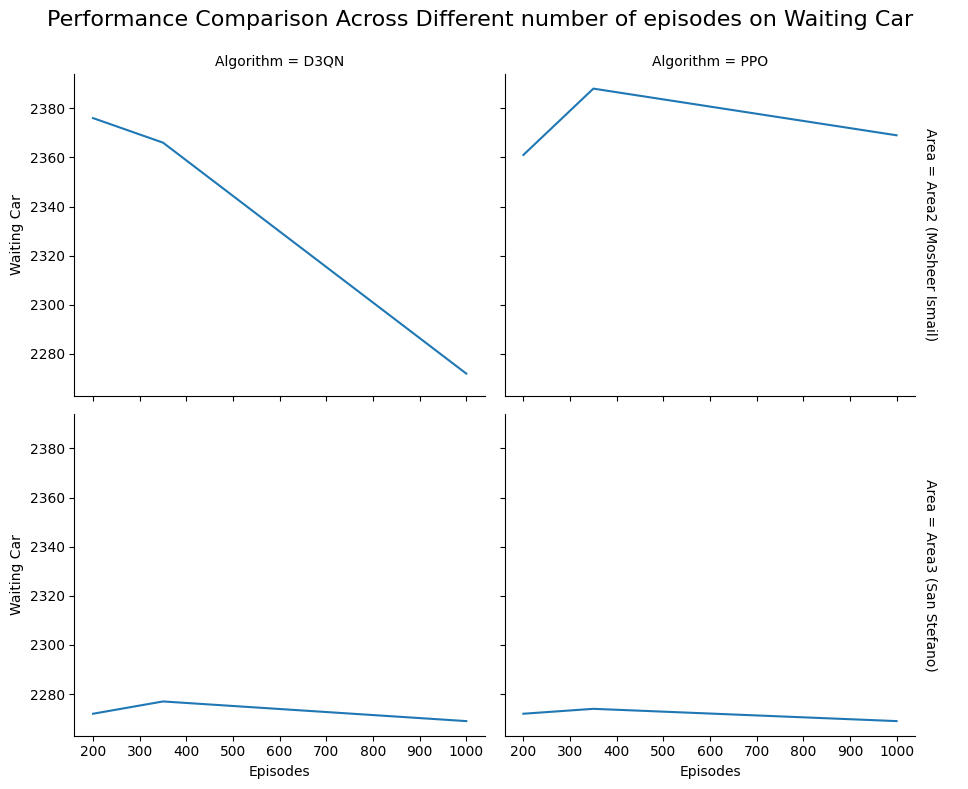

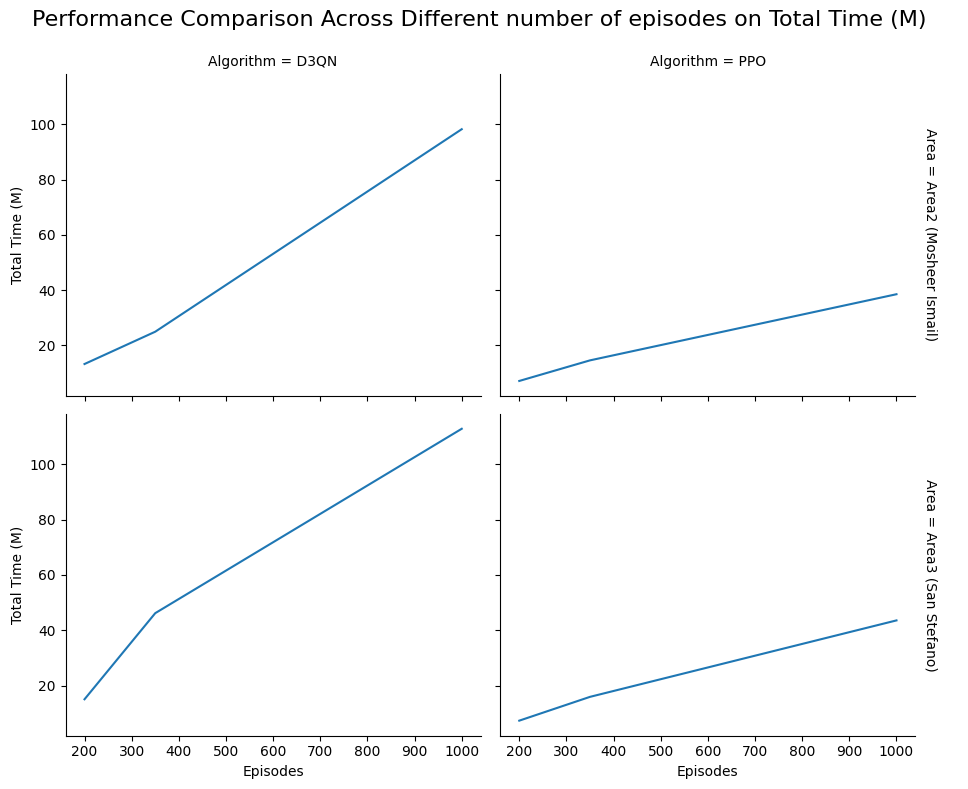

In [8]:
import seaborn as sns
for y_col in numeric_target_columns:
    if y_col not in ['Episodes','Max Sumo Steps(s)','Traffic Scale','Seed']:
        g = sns.FacetGrid(data_exp_episode_effect, col="Algorithm", row="Area" ,margin_titles=True,height=4, 
        aspect=1.2)
        g.map_dataframe(sns.lineplot, x='Episodes', y=y_col, errorbar="sd")
        g.add_legend()
        g.figure.suptitle("Performance Comparison Across Different number of episodes on "+y_col, fontsize=16)

        # Adjust layout so the title doesn't overlap with the plots
        g.figure.subplots_adjust(top=0.9)

#### ِAnalyzing on Sumo Steps

In [9]:
data_exp_sumo_effect = data_exp[data_exp['Study Group'].str.contains('Max Sumo Steps Effect;', na=False)]
data_exp_sumo_effect

,Area,Reward,Environment Type,Algorithm,Episodes,Max Sumo Steps(s),Traffic Scale,Seed,Runned By,Reward of Last Episode,...,Derivative of Reward,Waiting Time (s),Speed (m/s),Depart Delay (s),Time Loss (s),Waiting Car,Total Time (M),Device,Notes,Study Group
577,Area2 (Mosheer Ismail),Proposed,HighGroupedSumoEnv,D3QN,350,2000,0٫38,0,Ahmed,-13.4,...,6.994227010584536,63.44,8.13,394.56,95.38,2366.0,24.952,colab,NaN,Algorithm Performance; Episode Effect; Max Sum...
587,Area2 (Mosheer Ismail),Proposed,HighGroupedSumoEnv,D3QN,350,1500,0٫38,0,Marwa,-13.559,...,0.9645585018107443,60.16,8.23,296.89,90.31,1717.0,12.266,i5,NaN,Max Sumo Steps Effect;
597,Area2 (Mosheer Ismail),Proposed,HighGroupedSumoEnv,D3QN,350,4000,0٫38,0,Marwa,-28.92,...,10.347762650608985,69.34,8.28,778.09,102.61,4801.0,25.257,i5,NaN,Max Sumo Steps Effect;
667,Area2 (Mosheer Ismail),Proposed,HighGroupedSumoEnv,PPO,350,2000,0٫38,0,Taha,-19.054,...,3.82,67.76,2025-08-19 00:00:00,392.3,100.6,2388.0,14.588,colab,deterministic = False,Algorithm Performance; Episode Effect; Max Sum...
677,Area2 (Mosheer Ismail),Proposed,HighGroupedSumoEnv,PPO,350,1500,0٫38,0,Rimon,-13.053000450134277,...,3.351461410522461,63.21,8.15,271.6,94.56,1736.0,12.28,colab,NaN,Max Sumo Steps Effect;
687,Area2 (Mosheer Ismail),Proposed,HighGroupedSumoEnv,PPO,350,4000,0٫38,0,Rimon,-38.284000396728516,...,9.48275375366211,66.02,08.06,786.73,99.45,4774.0,19.734,colab,NaN,Max Sumo Steps Effect;
1297,Area3 (San Stefano),Proposed,HighGroupedSumoEnv,D3QN,350,2000,0٫38,0,Taha,37.503,...,13.57,21.62,24.8,724.19,109.41,2277.0,46.181,colab,NaN,Algorithm Performance; Episode Effect; Max Sum...
1307,Area3 (San Stefano),Proposed,HighGroupedSumoEnv,D3QN,350,1500,0٫38,0,Marwa,22.153,...,4.194350148485022,23.92,26.3,521.85,108.51,1692.0,16.565,i5,NaN,Max Sumo Steps Effect;
1317,Area3 (San Stefano),Proposed,HighGroupedSumoEnv,D3QN,350,4000,0٫38,0,Marwa,63.608,...,15.187459959647946,25.32,25.2,1502.39,114.49,4710.0,41.979,i5,NaN,Max Sumo Steps Effect;
1387,Area3 (San Stefano),Proposed,HighGroupedSumoEnv,PPO,350,2000,0٫38,0,Taha,28.348,...,6.29,25.57,24.89,716.4,113.46,2274.0,15.912,colab,NaN,Algorithm Performance; Episode Effect; Max Sum...


In [10]:
data_exp_sumo_effect = clean_data(data_exp_sumo_effect.copy(),numeric_target_columns)

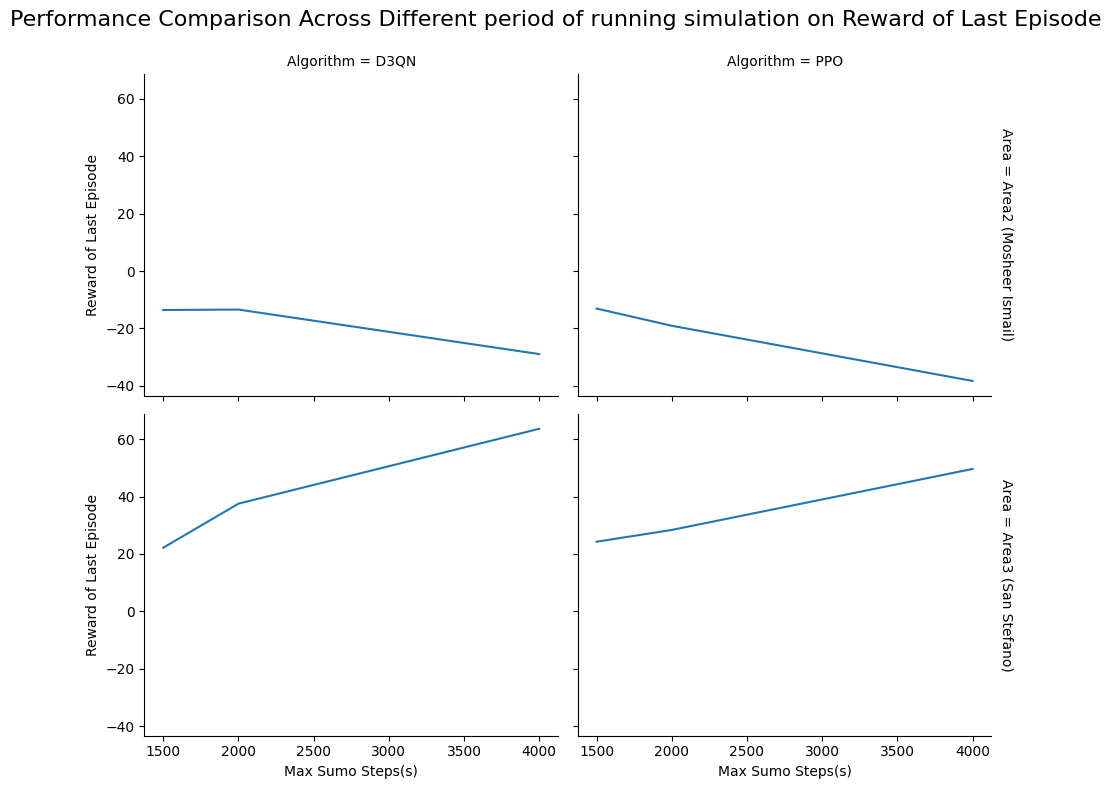

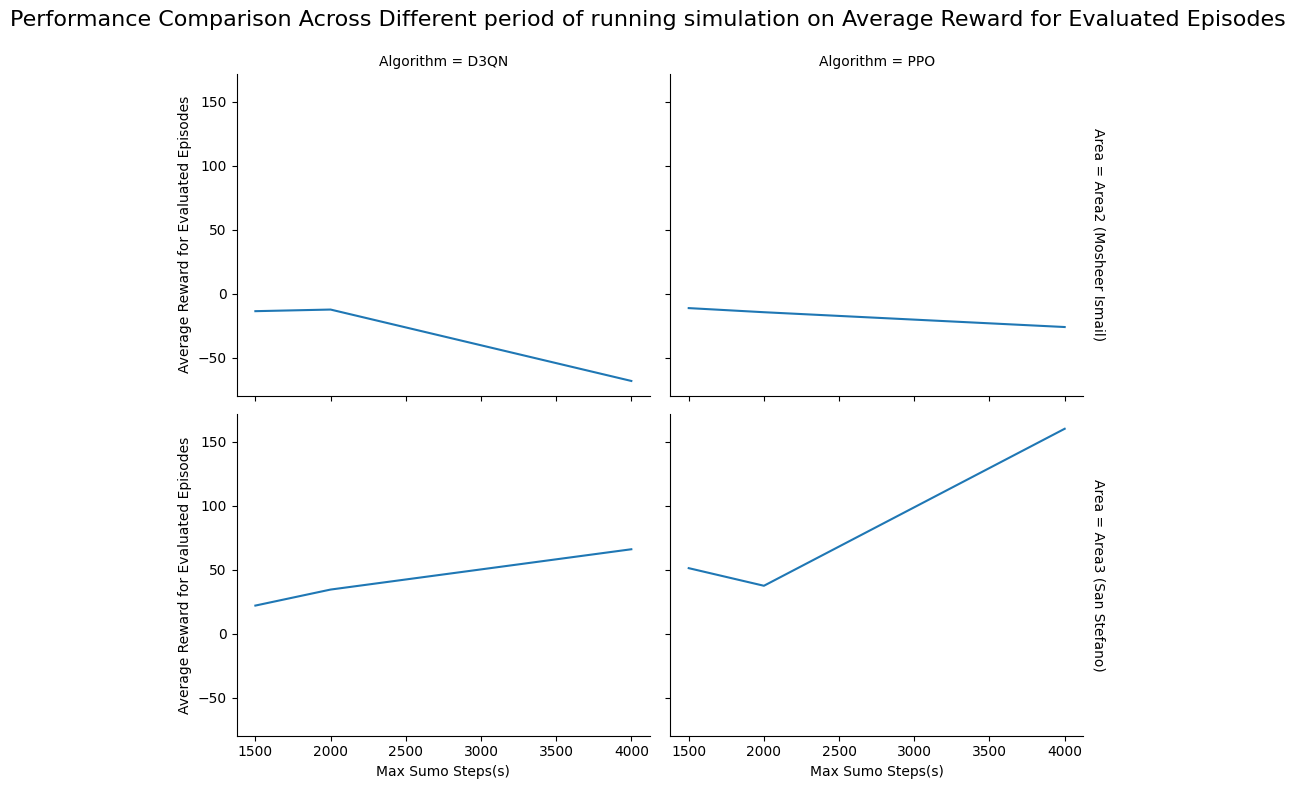

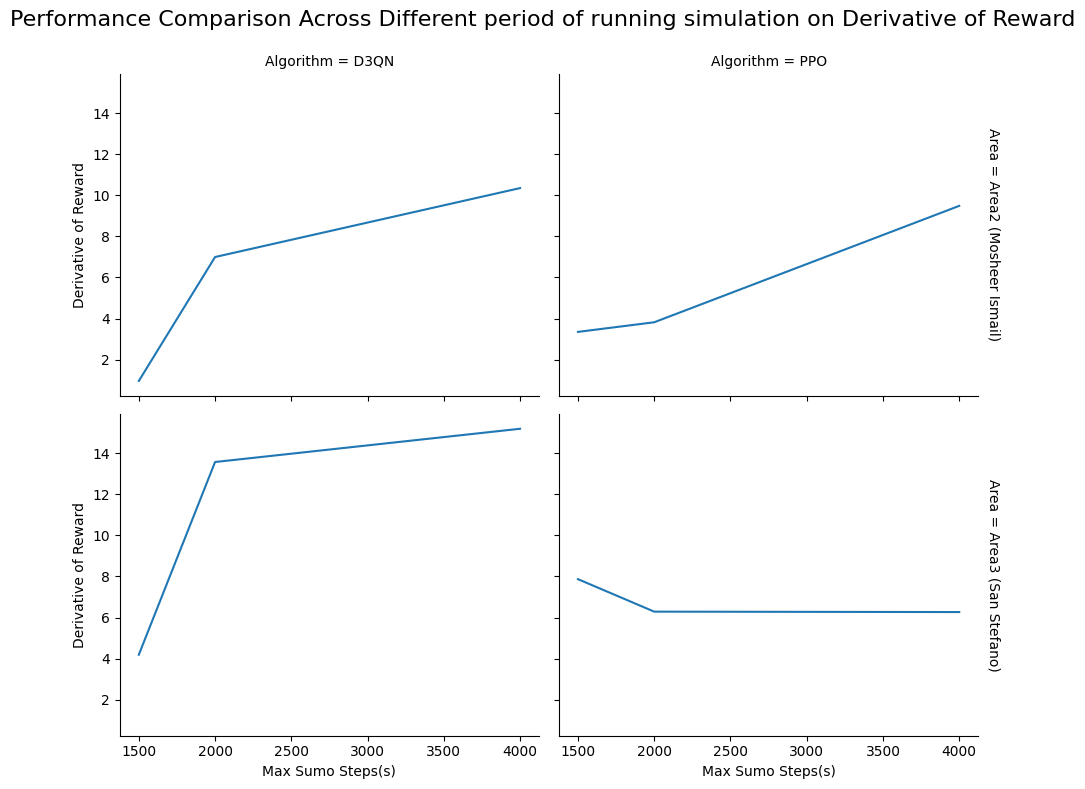

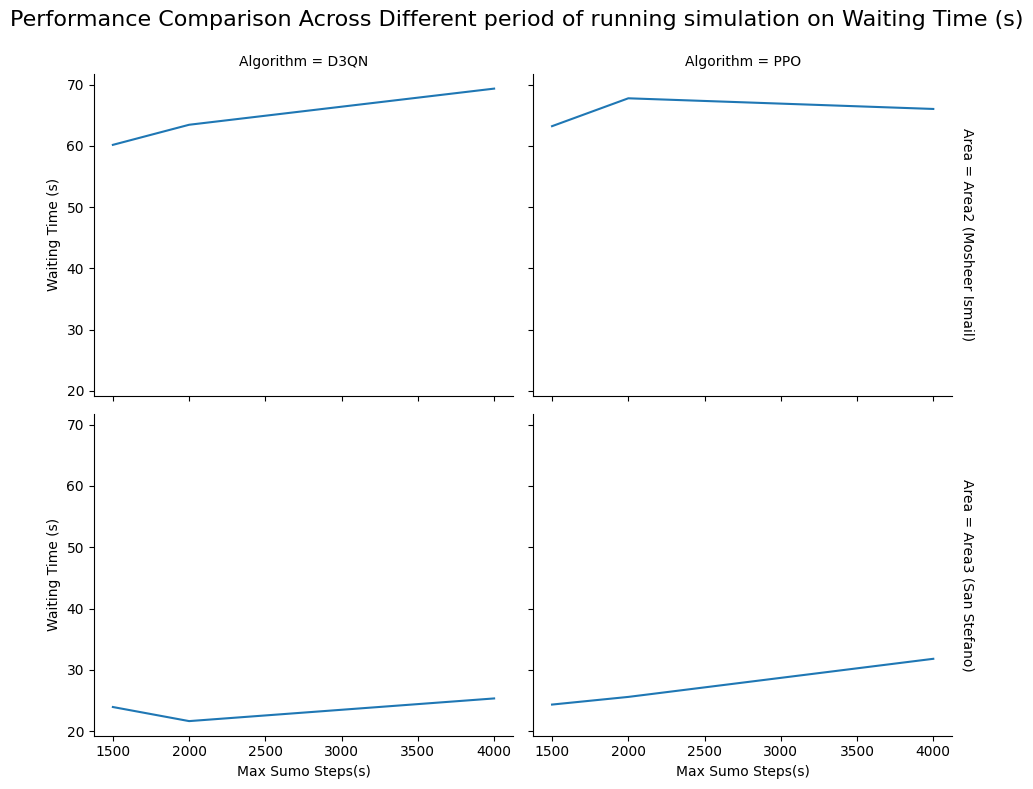

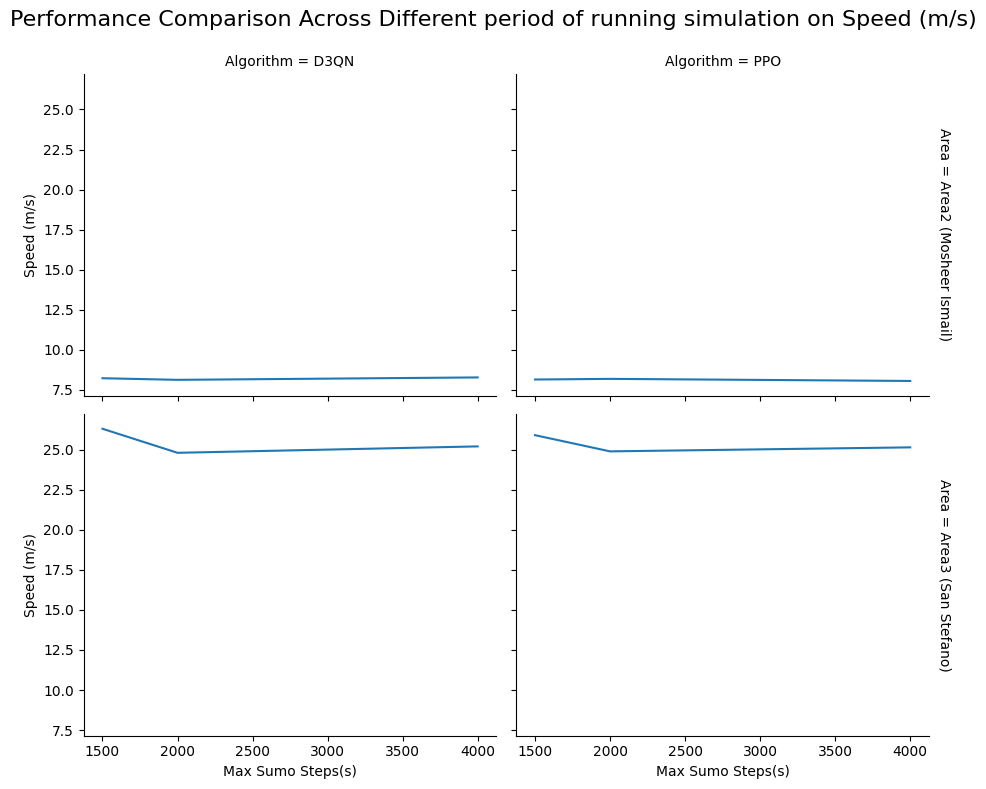

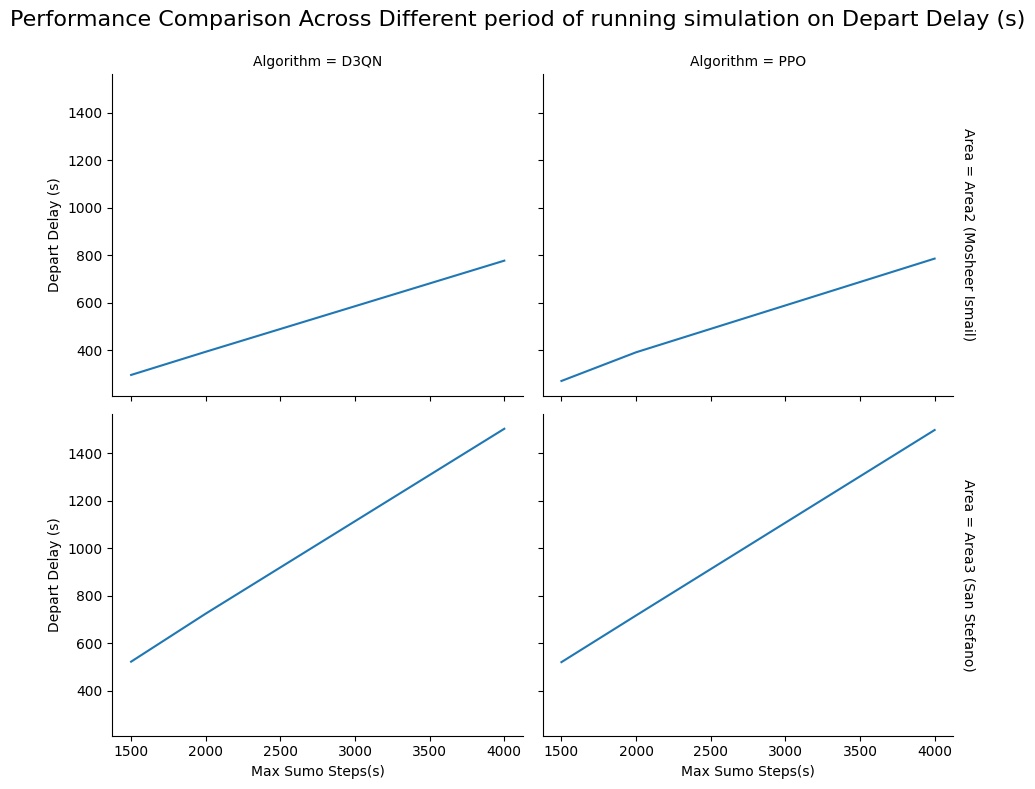

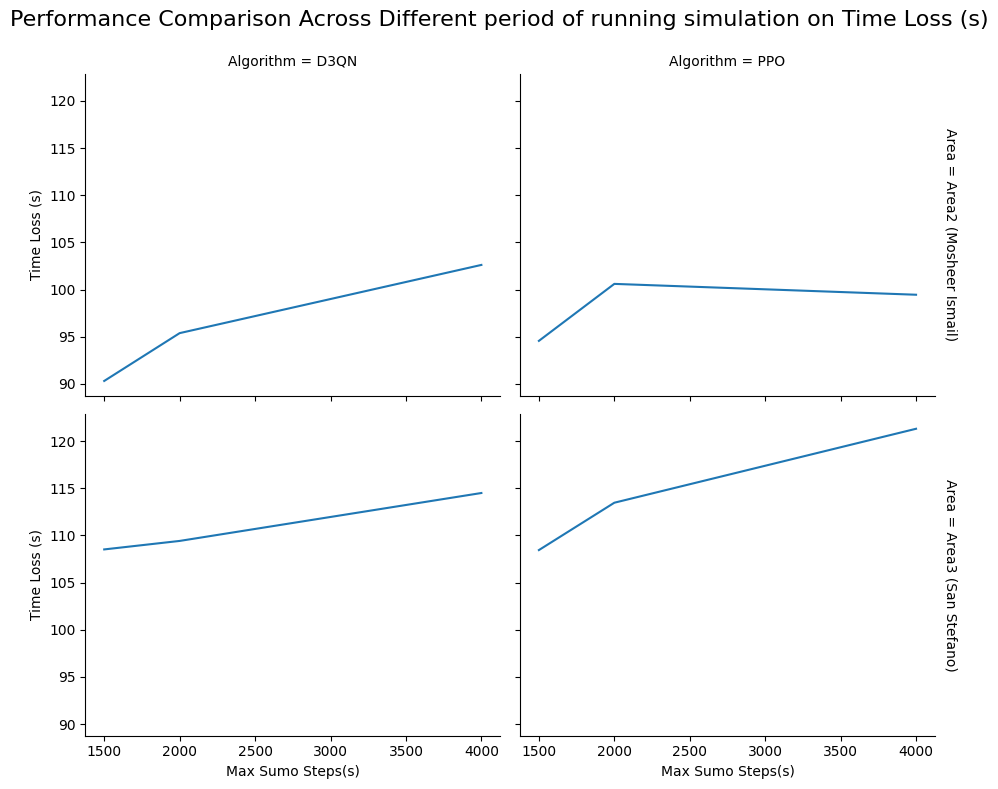

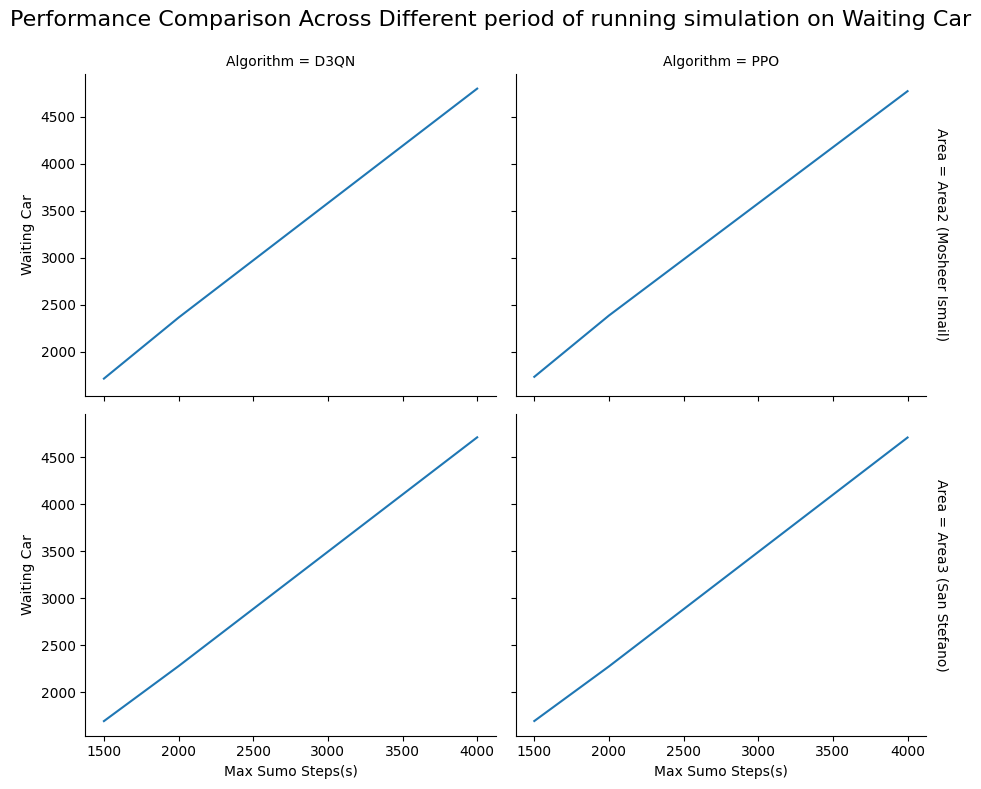

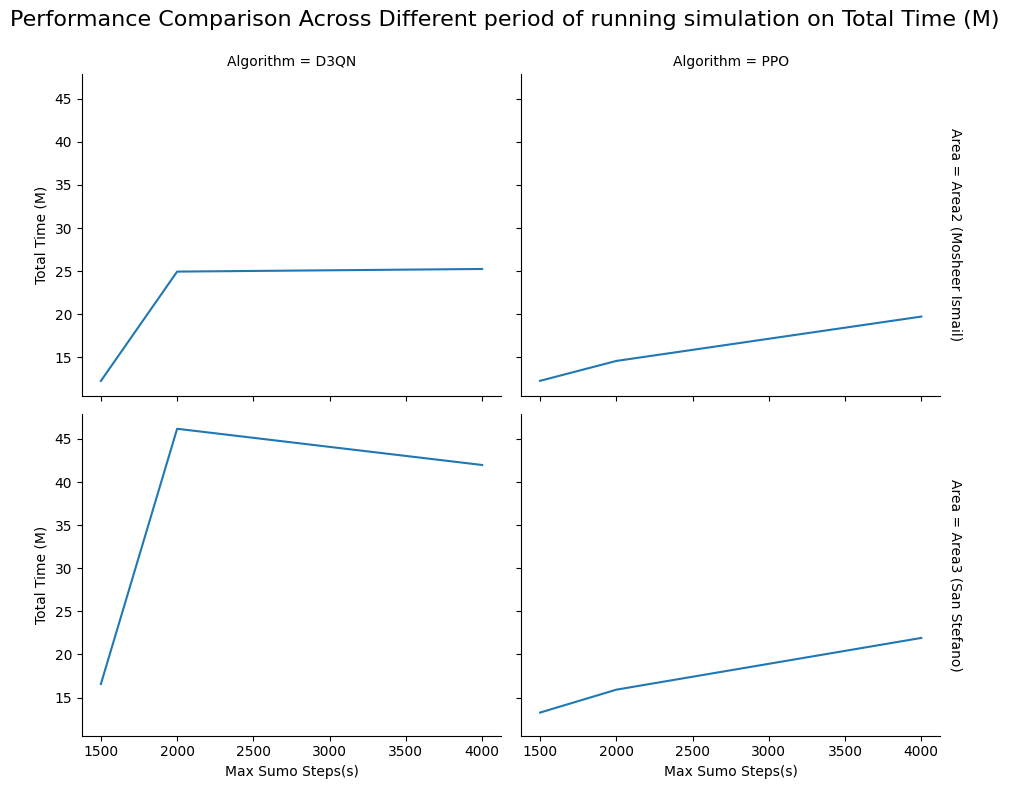

In [11]:
import seaborn as sns
for y_col in numeric_target_columns:
    if y_col not in ['Episodes','Max Sumo Steps(s)','Traffic Scale','Seed']:
        g = sns.FacetGrid(data_exp_sumo_effect, col="Algorithm", row="Area" ,margin_titles=True,height=4, 
        aspect=1.2)
        g.map_dataframe(sns.lineplot, x='Max Sumo Steps(s)', y=y_col, errorbar="sd")
        g.add_legend()
        g.figure.suptitle("Performance Comparison Across Different period of running simulation on "+y_col, fontsize=16)

        # Adjust layout so the title doesn't overlap with the plots
        g.figure.subplots_adjust(top=0.9)

## Further Analysis

### Preprocess for further experiments

In [6]:
mask = (
    (data_exp['Episodes'] == 350) &
    (data_exp['Max Sumo Steps(s)'] == 2000) &
    (data_exp['Seed'] != 'mean')
)

data_exp=data_exp[mask]

In [7]:
len(data_exp)


128

In [10]:
for col in ['Area', 'Reward', 'Environment Type', 'Algorithm', 'Episodes',
       'Max Sumo Steps(s)', 'Traffic Scale', 'Seed']:
    print(set(data_exp[col].values))

{'Area2 (Mosheer Ismail)', 'Area3 (San Stefano)'}
{'Proposed', 'Literature'}
{'HighGroupedSumoEnv', 'GroupedSumoEnv'}
{'PPO', 'D3QN'}
{350}
{2000}
{0.38, '0٫38', '0٫14'}
{'0', '1', '2', '3'}


In [8]:
data_exp.columns

Index(['Area', 'Reward', 'Environment Type', 'Algorithm', 'Episodes',
       'Max Sumo Steps(s)', 'Traffic Scale', 'Seed', 'Runned By',
       'Reward of Last Episode', 'Average Reward for Evaluated Episodes',
       'Derivative of Reward', 'Waiting Time (s)', 'Speed (m/s)',
       'Depart Delay (s)', 'Time Loss (s)', 'Waiting Car', 'Total Time (M)',
       'Device', 'Notes', 'Study Group'],
      dtype='object')

In [9]:
data_exp.dtypes

Area                                      object
Reward                                    object
Environment Type                          object
Algorithm                                 object
Episodes                                   int64
Max Sumo Steps(s)                          int64
Traffic Scale                             object
Seed                                      object
Runned By                                 object
Reward of Last Episode                    object
Average Reward for Evaluated Episodes     object
Derivative of Reward                      object
Waiting Time (s)                          object
Speed (m/s)                               object
Depart Delay (s)                          object
Time Loss (s)                             object
Waiting Car                              float64
Total Time (M)                            object
Device                                    object
Notes                                     object
Study Group         

In [10]:
data_exp = clean_data(data_exp.copy(),numeric_target_columns)

In [11]:
data_exp.select_dtypes(include='number').columns

Index(['Episodes', 'Max Sumo Steps(s)', 'Traffic Scale', 'Seed',
       'Reward of Last Episode', 'Average Reward for Evaluated Episodes',
       'Derivative of Reward', 'Waiting Time (s)', 'Speed (m/s)',
       'Depart Delay (s)', 'Time Loss (s)', 'Waiting Car', 'Total Time (M)'],
      dtype='object')

### Further Analysis of Data 2 (mosheer ismail)

In [12]:
set(data_exp['Area'].values)

{'Area2 (Mosheer Ismail)', 'Area3 (San Stefano)'}

In [13]:
analysis_mask = (
    (data_exp['Area'] == 'Area2 (Mosheer Ismail)') 
)

data_2_exp=data_exp[analysis_mask]

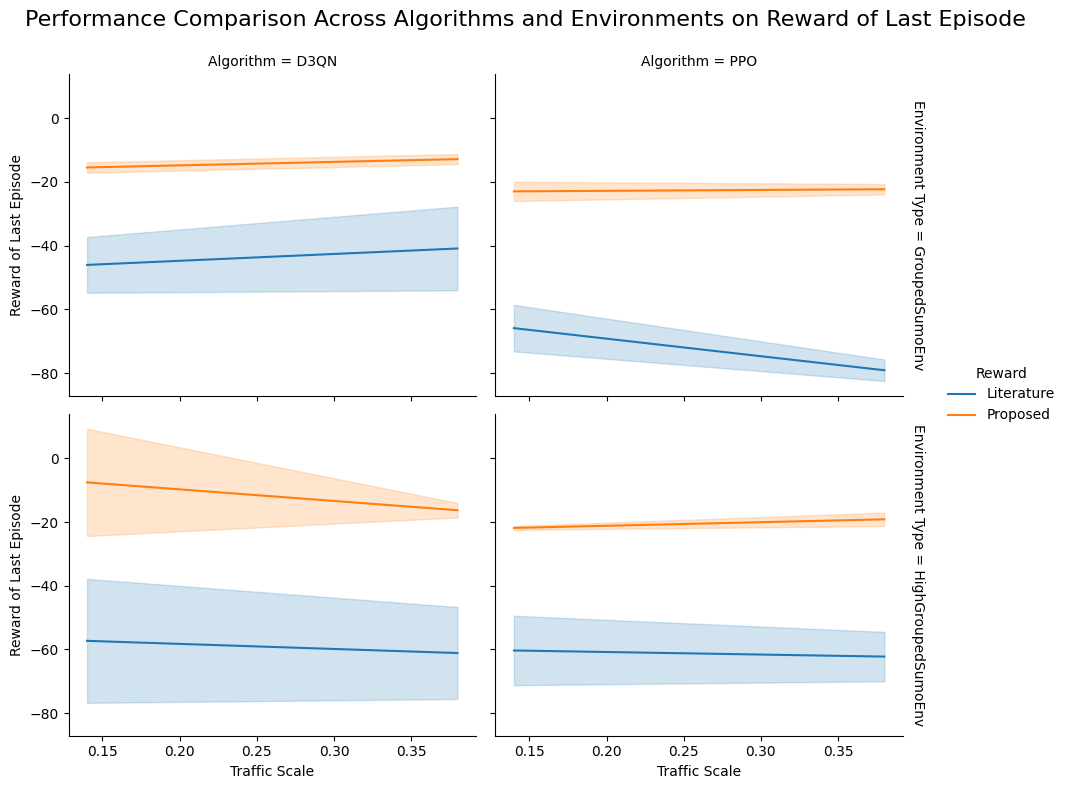

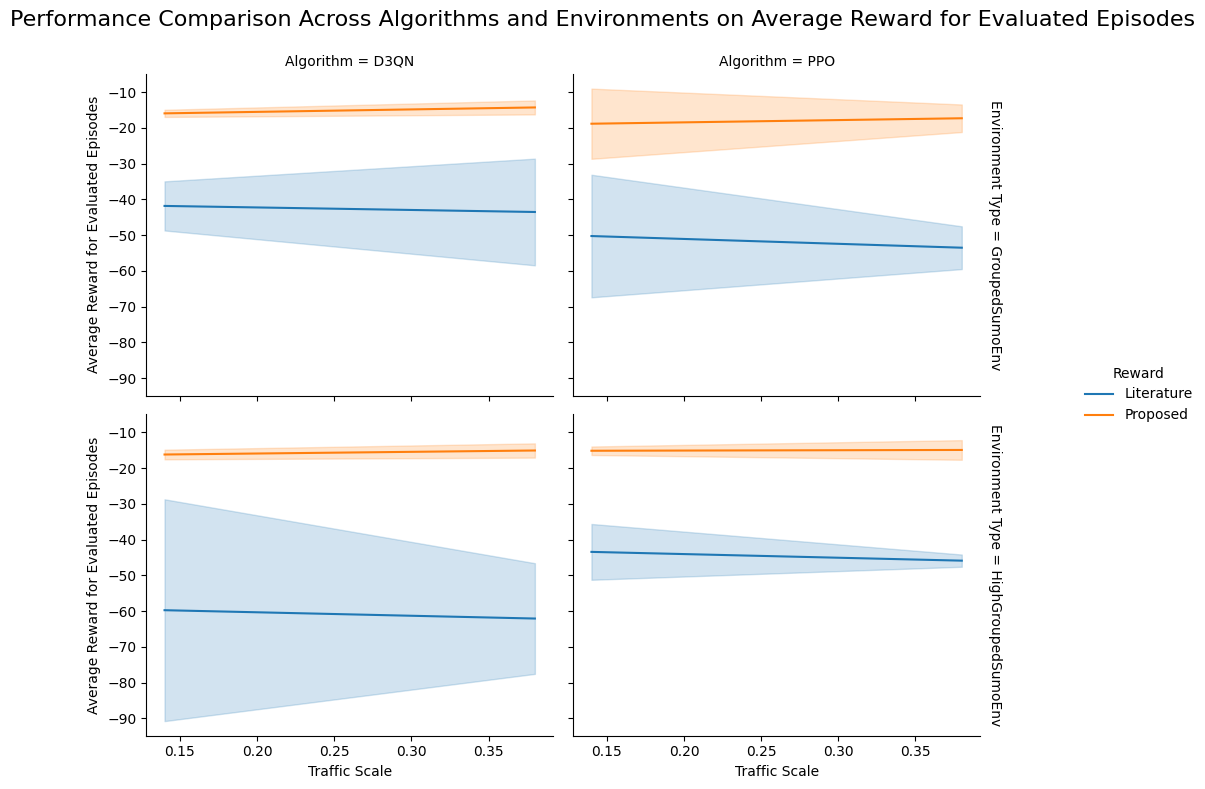

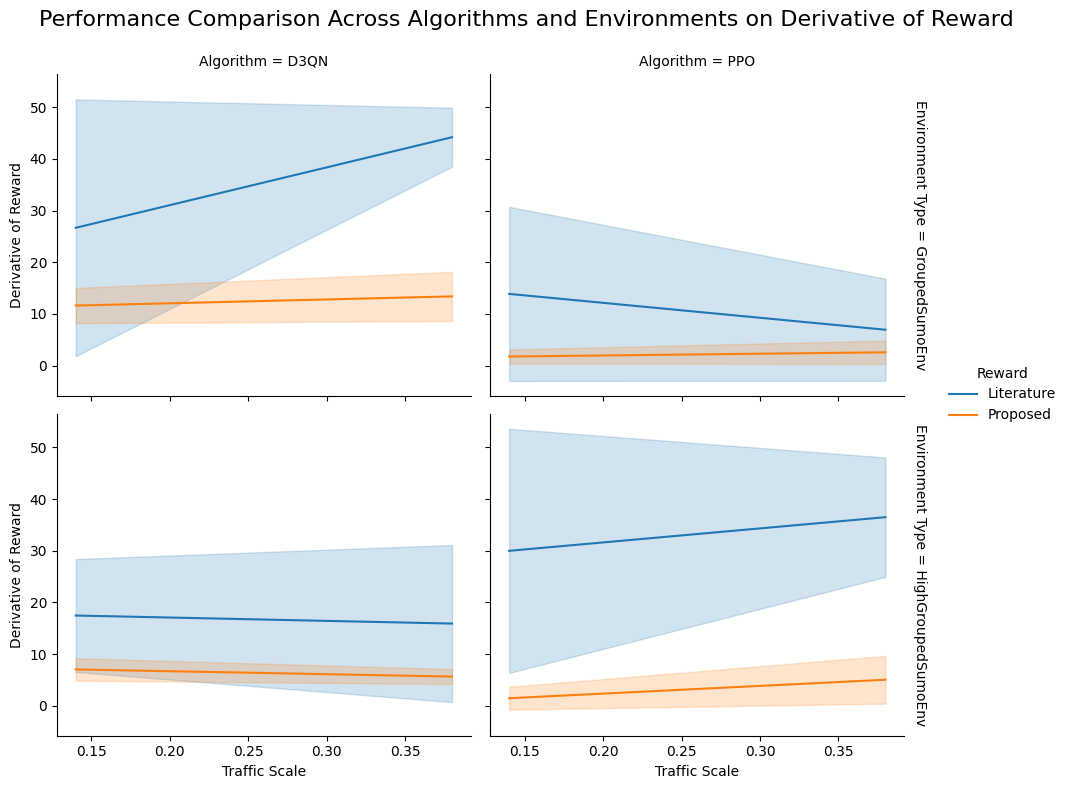

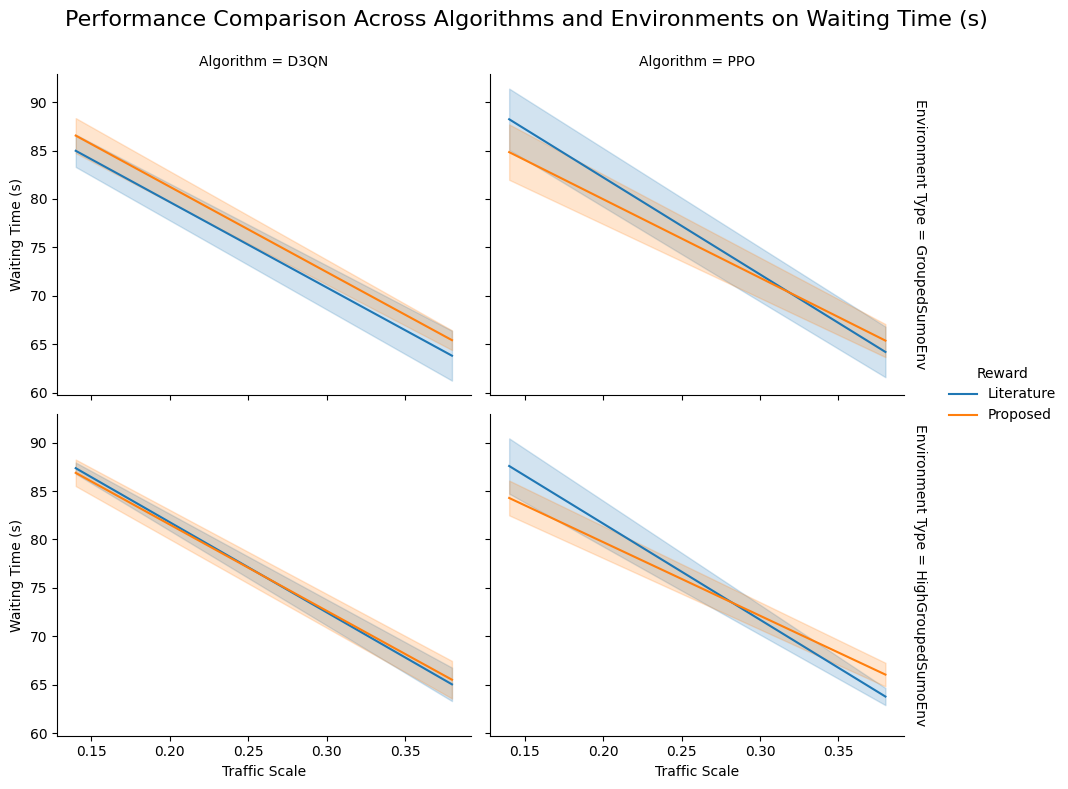

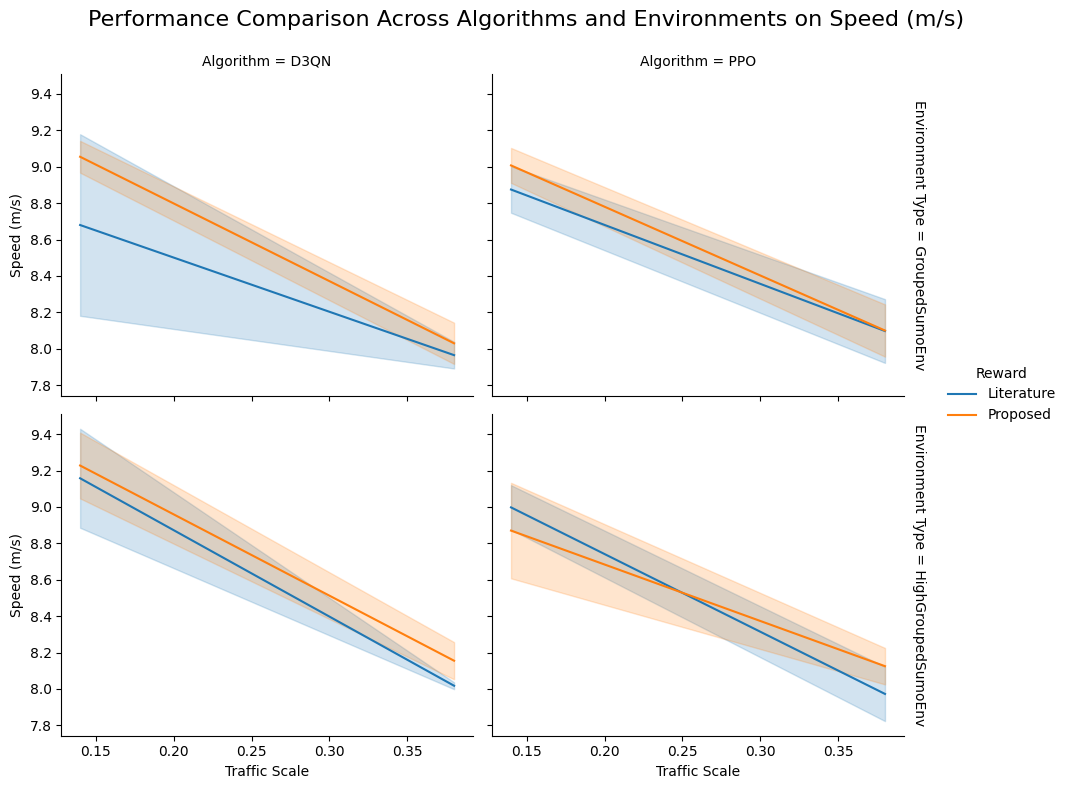

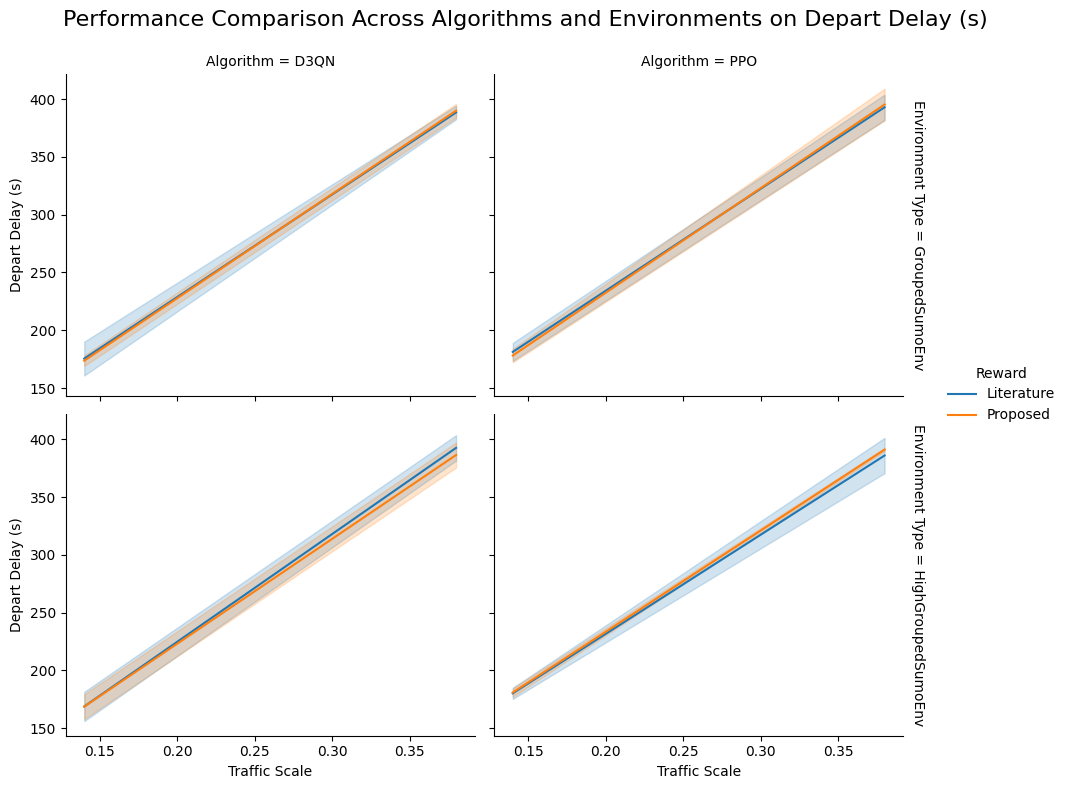

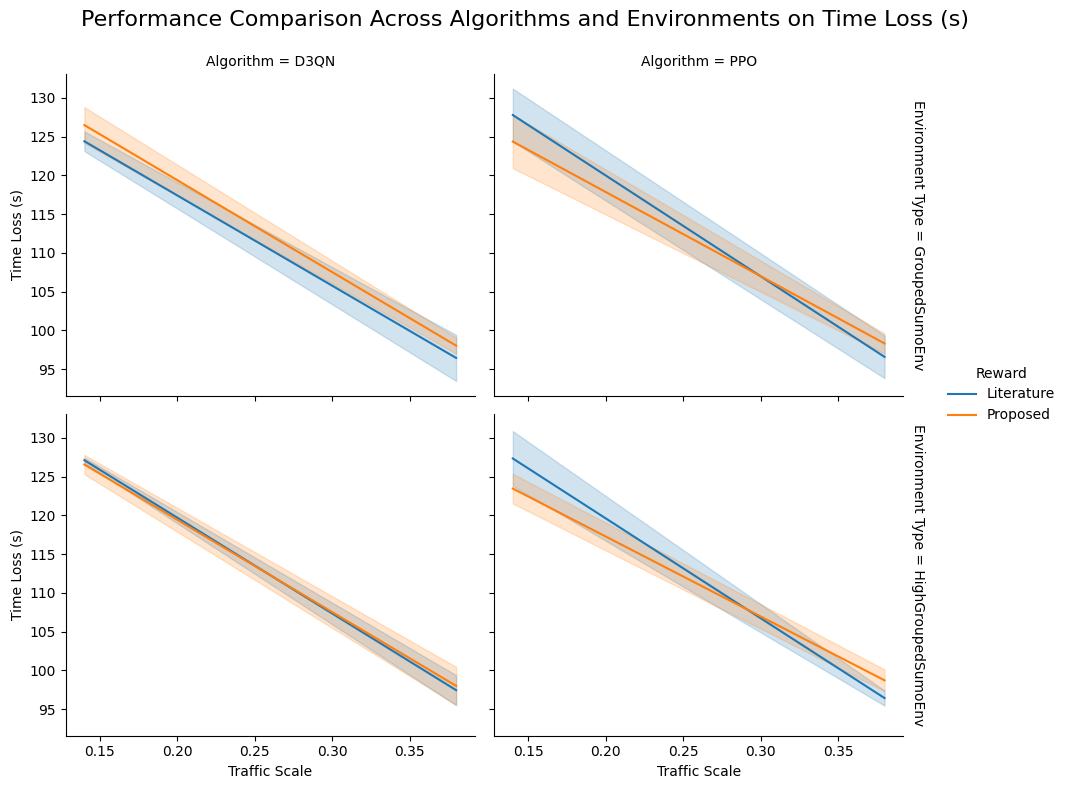

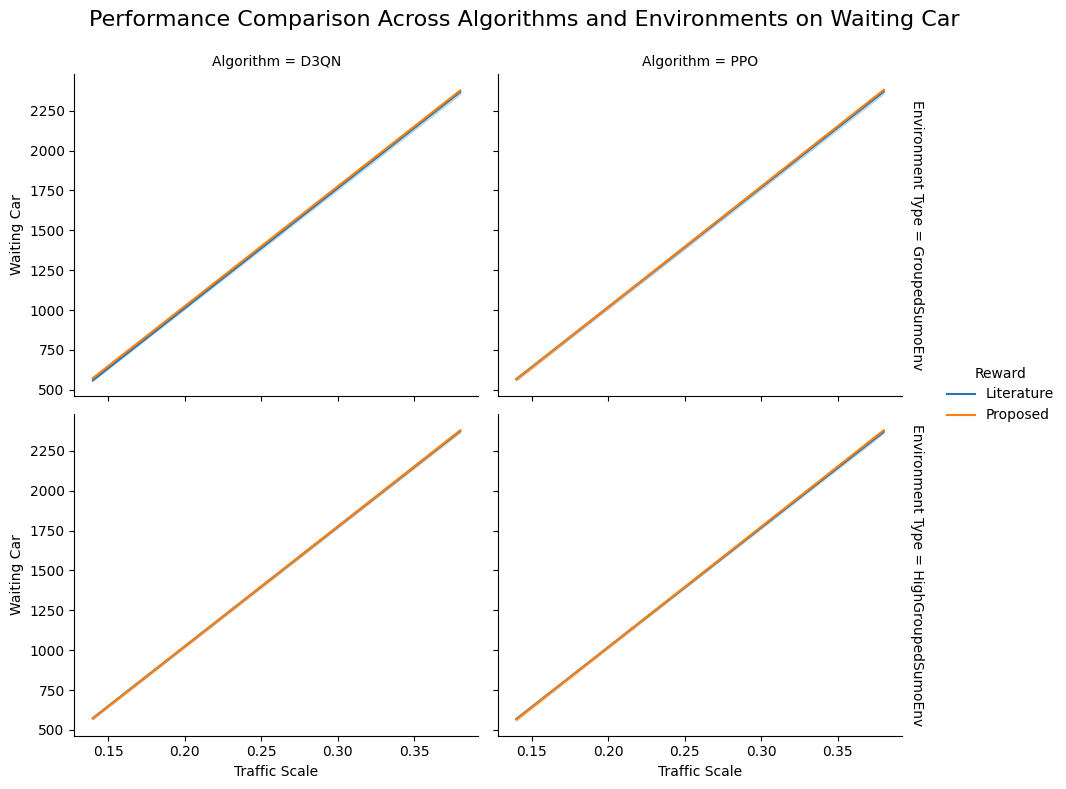

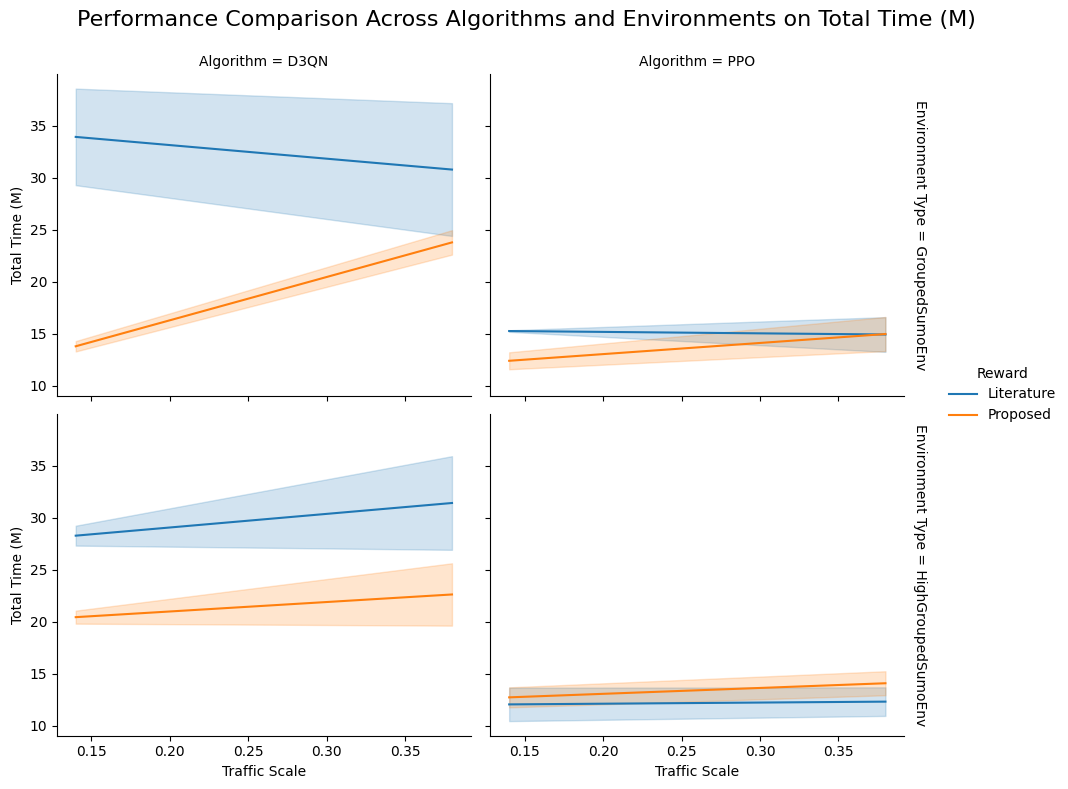

In [14]:
import seaborn as sns
for y_col in numeric_target_columns:
    if y_col not in ['Episodes','Max Sumo Steps(s)','Traffic Scale','Seed']:
        g = sns.FacetGrid(data_2_exp, col="Algorithm", row="Environment Type", hue="Reward" ,margin_titles=True,height=4, 
        aspect=1.2)
        g.map_dataframe(sns.lineplot, x="Traffic Scale", y=y_col, errorbar="sd")
        g.add_legend()
        g.figure.suptitle("Performance Comparison Across Algorithms and Environments on "+y_col, fontsize=16)

        # Adjust layout so the title doesn't overlap with the plots
        g.figure.subplots_adjust(top=0.9)

In [15]:
data_exp_i_seed_groubed = get_grouped_seed(data_2_exp)
data_exp_i_seed_groubed


,Area,Reward,Environment Type,Algorithm,Runned By,Device,Notes,Study Group,Episodes,Max Sumo Steps(s),...,Seed,Reward of Last Episode,Average Reward for Evaluated Episodes,Derivative of Reward,Waiting Time (s),Speed (m/s),Depart Delay (s),Time Loss (s),Waiting Car,Total Time (M)
0,Area2 (Mosheer Ismail),Literature,GroupedSumoEnv,D3QN,Rimon,colab,without variation,Exp2,350.0,2000.0,...,1.5,-46.053500,-41.834531,26.672656,84.9800,8.68000,175.4500,124.3925,559.75,33.91450
1,Area2 (Mosheer Ismail),Literature,GroupedSumoEnv,D3QN,Taha,colab,NaN,Exp2,350.0,2000.0,...,1.5,-40.904250,-43.530000,44.201172,63.8050,7.96500,388.3900,96.4325,2367.75,30.77475
2,Area2 (Mosheer Ismail),Literature,GroupedSumoEnv,PPO,Rimon,colab,NaN,Exp2,350.0,2000.0,...,1.5,-65.903999,-50.258202,13.884366,88.2375,8.87500,181.2300,127.7800,567.50,15.24750
3,Area2 (Mosheer Ismail),Literature,GroupedSumoEnv,PPO,Rimon,colab,NaN,Exp2,350.0,2000.0,...,1.5,-79.120499,-53.520702,6.950394,64.1925,8.09750,392.9025,96.5650,2370.50,14.91325
4,Area2 (Mosheer Ismail),Literature,HighGroupedSumoEnv,D3QN,Ahmed,colab,NaN,Exp2,350.0,2000.0,...,1.5,-57.286000,-59.771406,17.469047,87.3650,9.15750,168.7775,127.1325,573.75,28.27875
5,Area2 (Mosheer Ismail),Literature,HighGroupedSumoEnv,D3QN,Taha,colab,NaN,Reward Function Effect;,350.0,2000.0,...,1.5,-61.112000,-62.102875,15.912500,65.0275,8.01750,392.5000,97.4550,2374.50,31.42000
6,Area2 (Mosheer Ismail),Literature,HighGroupedSumoEnv,PPO,Taha,colab,NaN,Exp2,350.0,2000.0,...,1.5,-60.311499,-43.459179,29.986765,87.5900,8.99750,180.1625,127.3525,569.50,12.05325
7,Area2 (Mosheer Ismail),Literature,HighGroupedSumoEnv,PPO,Taha,colab,NaN,Reward Function Effect;,350.0,2000.0,...,1.5,-62.233000,-45.911721,36.495754,63.7650,7.97250,385.9000,96.4325,2370.00,12.31825
8,Area2 (Mosheer Ismail),Proposed,GroupedSumoEnv,D3QN,Marwa,i5,NaN,Exp2,350.0,2000.0,...,1.5,-15.467250,-15.941726,11.625532,86.5500,9.05500,173.6275,126.4850,573.00,13.78075
9,Area2 (Mosheer Ismail),Proposed,GroupedSumoEnv,D3QN,Taha,colab,"D3QN may give stable results training ,evaluation",Environment Type Effect;,350.0,2000.0,...,1.5,-12.847000,-14.287500,13.400000,65.4100,8.03000,389.9400,98.0200,2377.00,23.76975


In [16]:
main_numeric_columns = [i for i in numeric_target_columns if i not in ['Episodes', 'Max Sumo Steps(s)', 'Traffic Scale', 'Seed',]]

for i in range(len(data_exp_i_seed_groubed)):
    row = data_exp_i_seed_groubed.iloc[i]
    title = f"Summary of seeds at Environment {row['Environment Type']} ,Reward {row['Reward']} , Algorithm {row['Algorithm']} ,Scale {row['Traffic Scale']}"
    fig = plot_spider_interactive(row[main_numeric_columns],title)
    #fig.write_html("chart.html")
    


### Further Analysis of Data 3 (San Stefano)

In [17]:
analysis_mask = (
    (data_exp['Area'] == 'Area3 (San Stefano)') 
)

data_3_exp=data_exp[analysis_mask]

In [18]:
numeric_target_columns

['Episodes',
 'Max Sumo Steps(s)',
 'Traffic Scale',
 'Seed',
 'Reward of Last Episode',
 'Average Reward for Evaluated Episodes',
 'Derivative of Reward',
 'Waiting Time (s)',
 'Speed (m/s)',
 'Depart Delay (s)',
 'Time Loss (s)',
 'Waiting Car',
 'Total Time (M)']

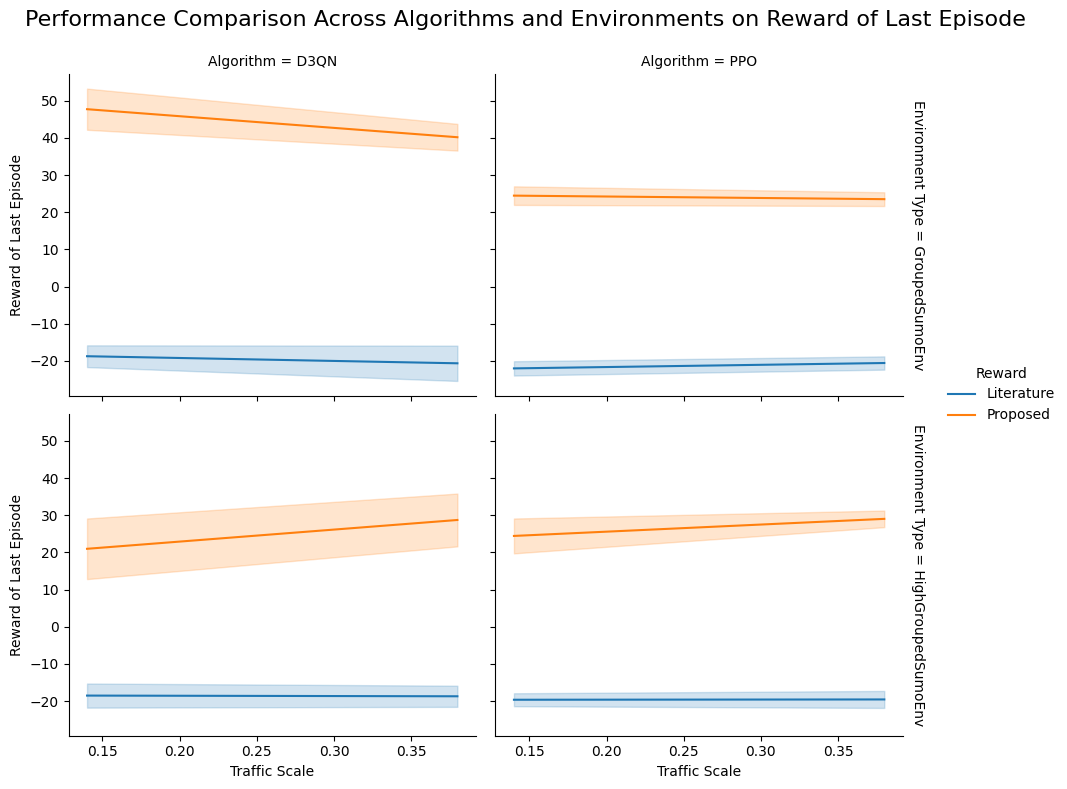

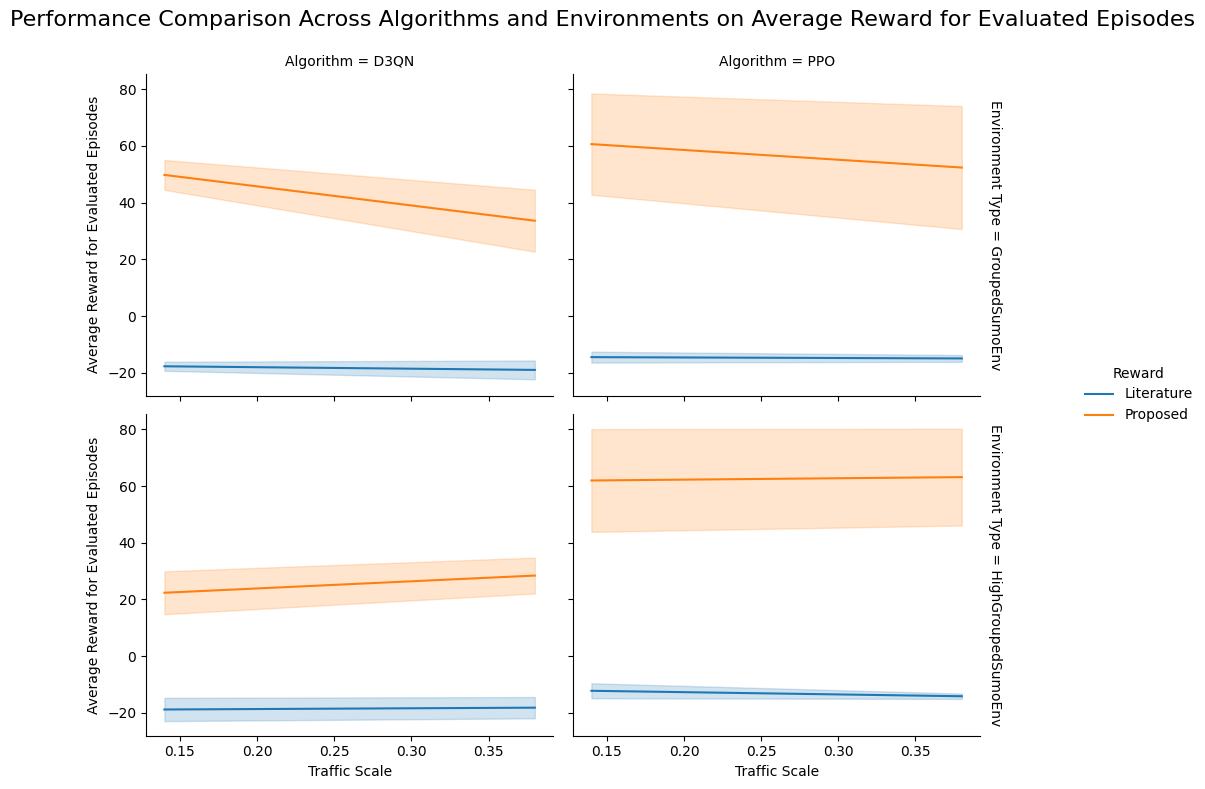

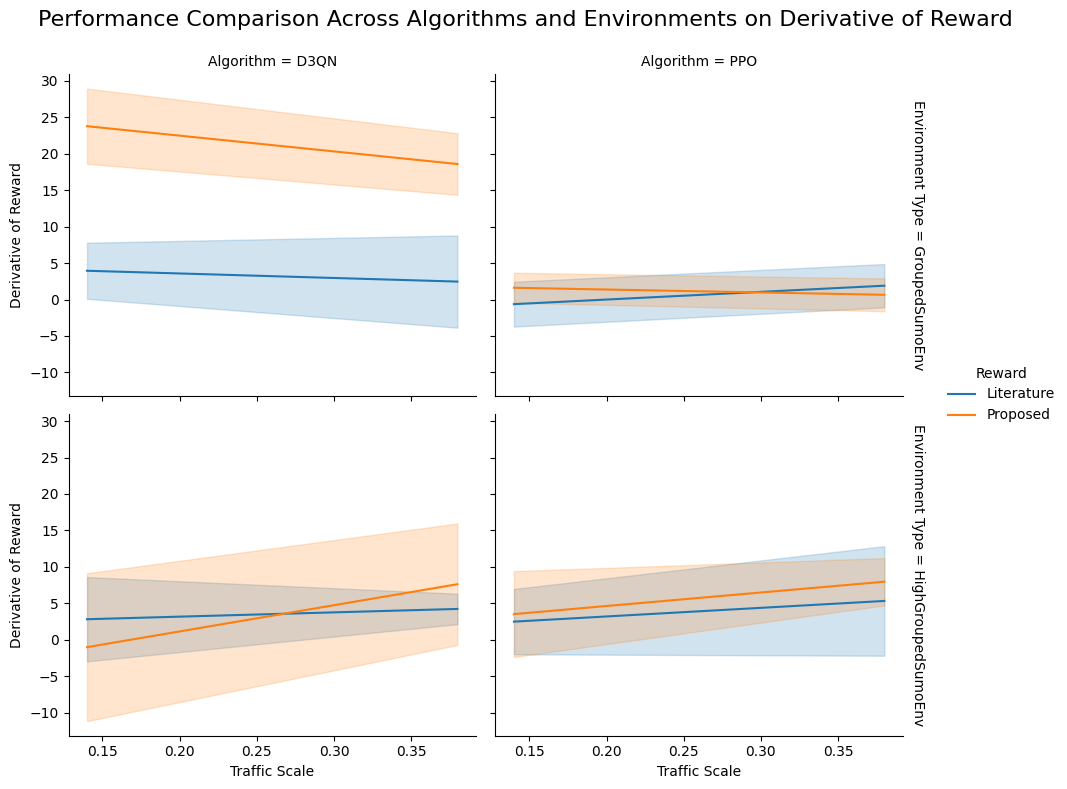

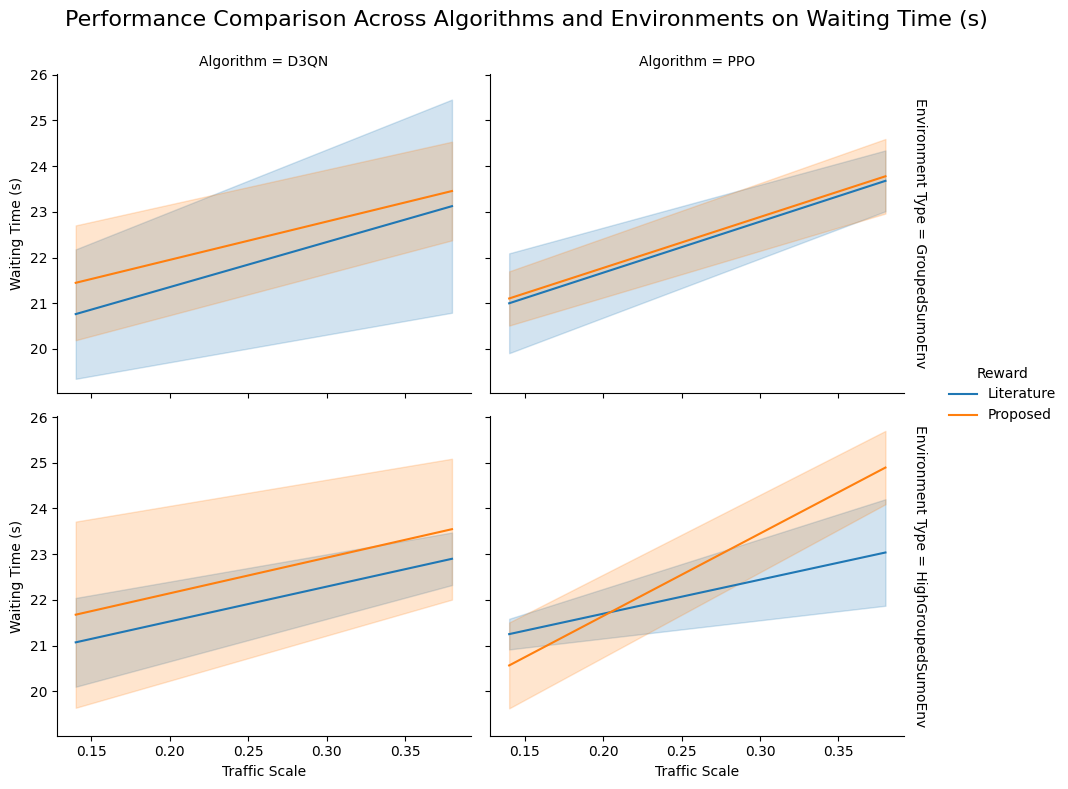

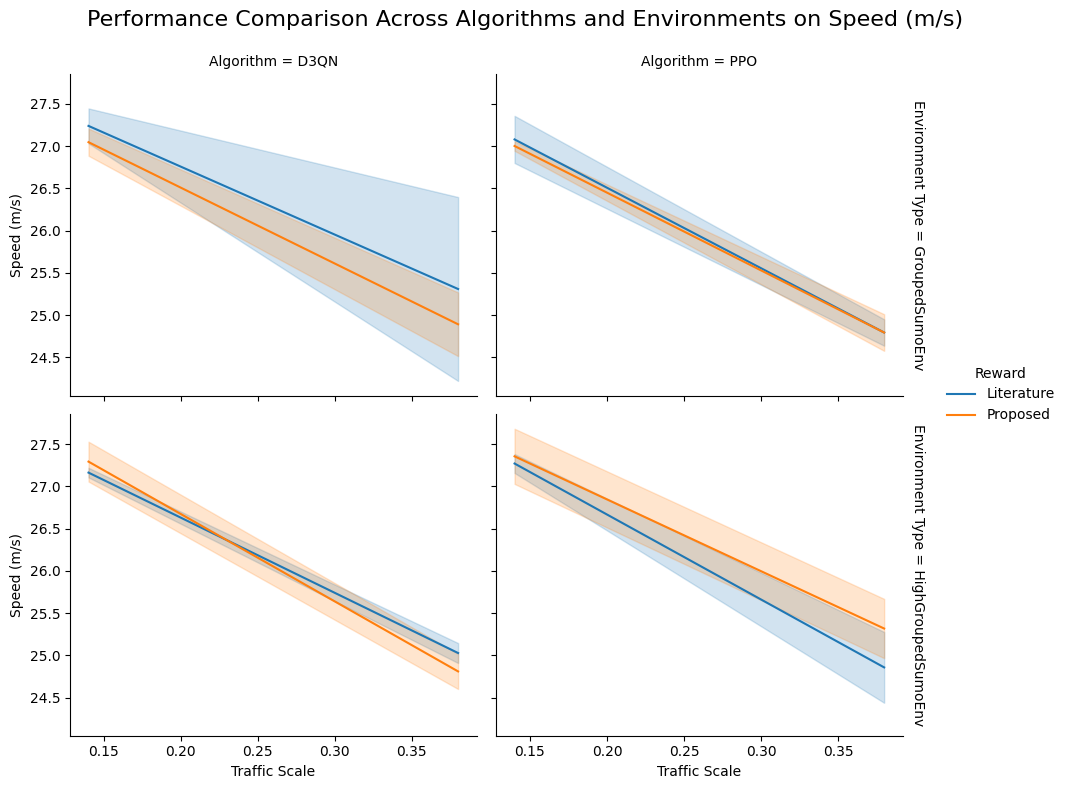

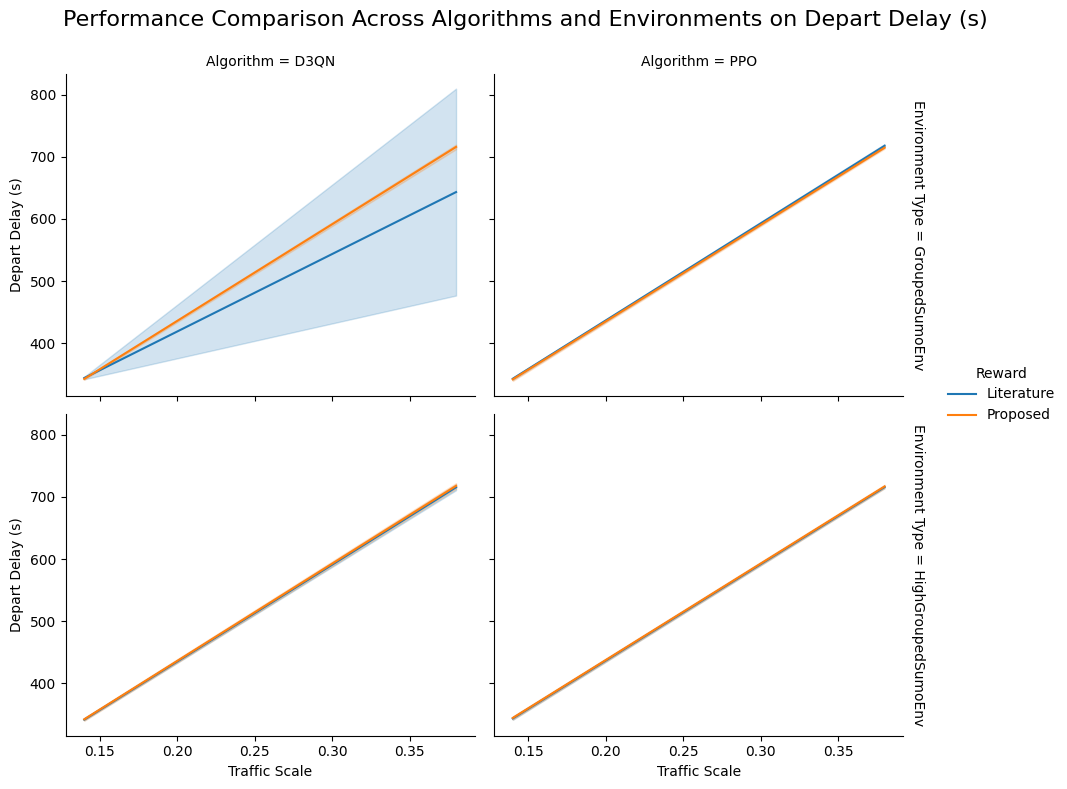

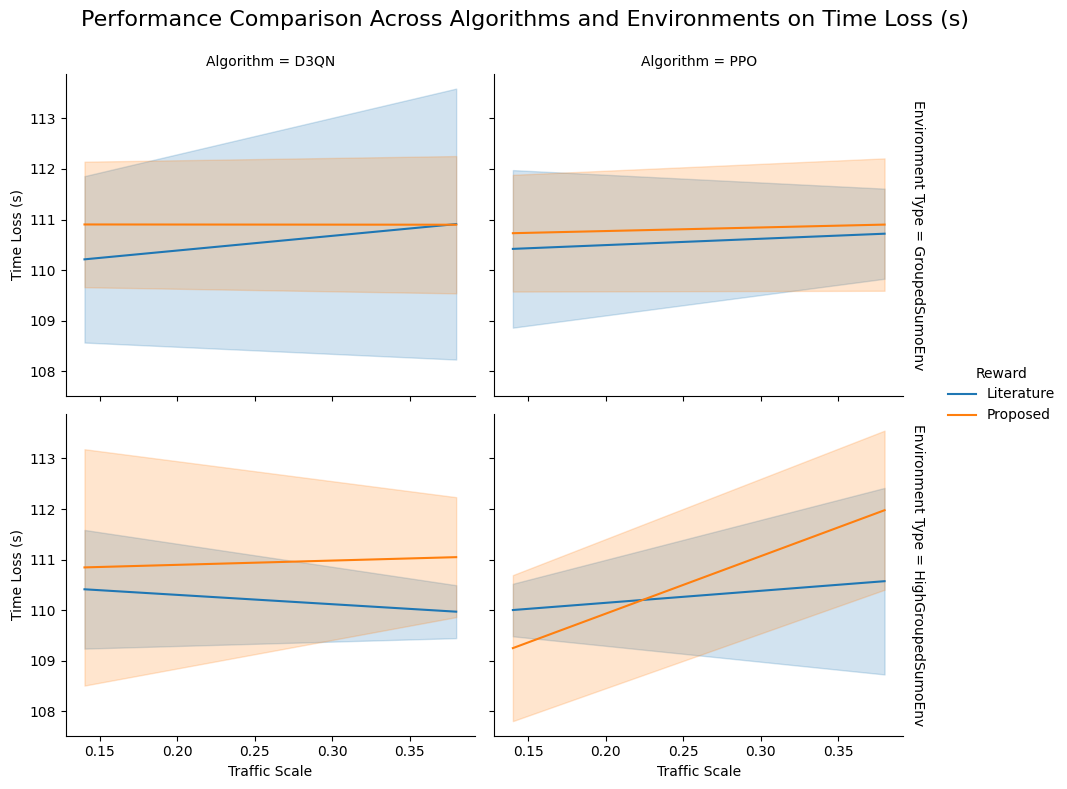

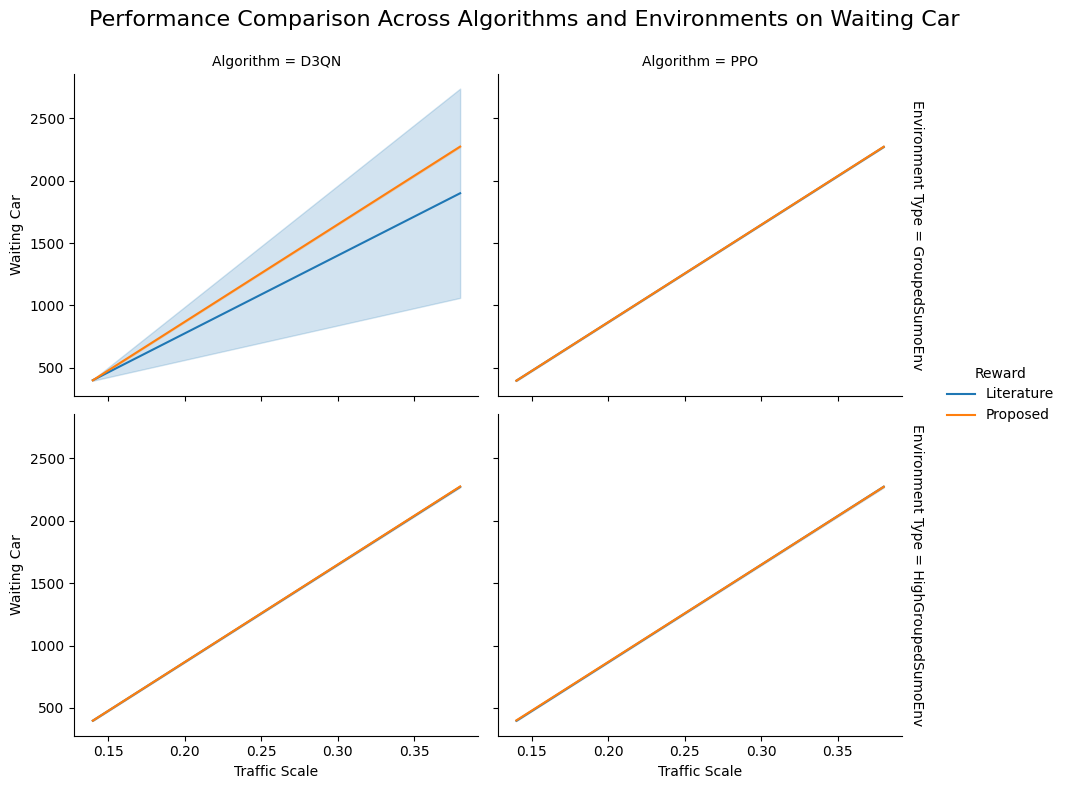

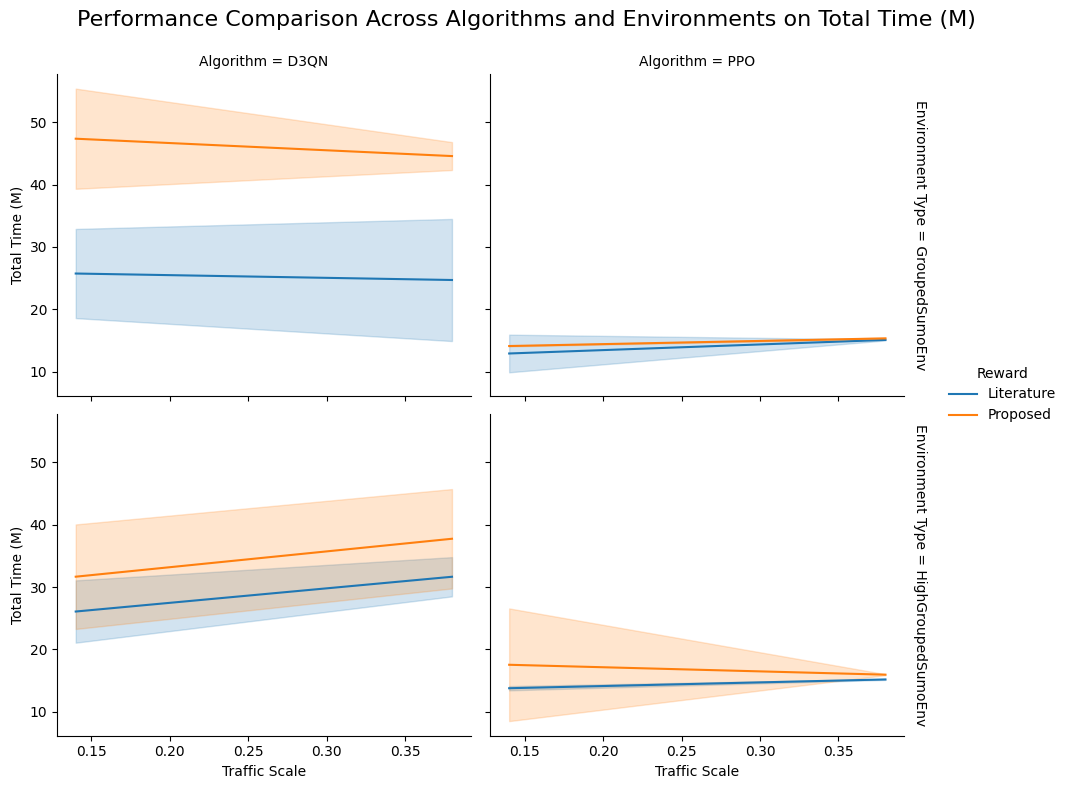

In [19]:
import seaborn as sns
for y_col in numeric_target_columns:
    if y_col not in ['Episodes','Max Sumo Steps(s)','Traffic Scale','Seed']:
        g = sns.FacetGrid(data_3_exp, col="Algorithm", row="Environment Type", hue="Reward" ,margin_titles=True,height=4, 
        aspect=1.2)
        g.map_dataframe(sns.lineplot, x="Traffic Scale", y=y_col, errorbar="sd")
        g.add_legend()
        g.figure.suptitle("Performance Comparison Across Algorithms and Environments on "+y_col, fontsize=16)

        # Adjust layout so the title doesn't overlap with the plots
        g.figure.subplots_adjust(top=0.9)

In [20]:
data_exp_i_seed_groubed = get_grouped_seed(data_3_exp)
data_exp_i_seed_groubed

,Area,Reward,Environment Type,Algorithm,Runned By,Device,Notes,Study Group,Episodes,Max Sumo Steps(s),...,Seed,Reward of Last Episode,Average Reward for Evaluated Episodes,Derivative of Reward,Waiting Time (s),Speed (m/s),Depart Delay (s),Time Loss (s),Waiting Car,Total Time (M)
0,Area3 (San Stefano),Literature,GroupedSumoEnv,D3QN,Marwa,i5,NaN,Exp2,350.0,2000.0,...,1.5,-18.79525,-17.647547,4.187079,20.7550,27.2275,344.2925,110.0225,399.50,24.93300
1,Area3 (San Stefano),Literature,GroupedSumoEnv,D3QN,Marwa,i5,NaN,Exp2,350.0,2000.0,...,1.5,-21.04175,-19.389795,1.859519,23.7225,24.8400,717.6850,111.2750,2274.50,25.25700
2,Area3 (San Stefano),Literature,GroupedSumoEnv,PPO,Marwa,i5,NaN,Exp2,350.0,2000.0,...,1.5,-22.00450,-14.498737,-0.631985,21.0000,27.0800,342.7525,110.4200,396.00,12.92325
3,Area3 (San Stefano),Literature,GroupedSumoEnv,PPO,Taha,colab,NaN,Exp2,350.0,2000.0,...,1.5,-20.55750,-14.955000,1.901250,23.6775,24.7950,717.7175,110.7200,2270.75,15.09650
4,Area3 (San Stefano),Literature,HighGroupedSumoEnv,D3QN,Marwa,i5,NaN,Exp2,350.0,2000.0,...,1.5,-18.51600,-18.801723,2.811153,21.0725,27.1625,341.6075,110.4150,397.00,26.08850
5,Area3 (San Stefano),Literature,HighGroupedSumoEnv,D3QN,Rimon,colab,NaN,Reward Function Effect;,350.0,2000.0,...,1.5,-18.70375,-18.158300,4.222435,22.9000,25.0275,715.5550,109.9725,2272.75,31.66225
6,Area3 (San Stefano),Literature,HighGroupedSumoEnv,PPO,Taha,colab,NaN,Exp2,350.0,2000.0,...,1.5,-19.63650,-12.207000,2.480000,21.2525,27.2700,343.5125,110.0050,396.25,13.79075
7,Area3 (San Stefano),Literature,HighGroupedSumoEnv,PPO,Rimon,colab,NaN,Reward Function Effect;,350.0,2000.0,...,1.5,-19.55500,-14.130288,5.318486,23.0375,24.8575,715.9725,110.5750,2273.75,15.19700
8,Area3 (San Stefano),Proposed,GroupedSumoEnv,D3QN,taha,colab,NaN,Exp2,350.0,2000.0,...,1.5,47.74775,49.750750,23.790000,21.4475,27.0475,342.4700,110.9025,399.00,47.36025
9,Area3 (San Stefano),Proposed,GroupedSumoEnv,D3QN,taha,colab,NaN,Environment Type Effect;,350.0,2000.0,...,1.5,40.20300,33.601500,18.600000,23.4550,24.8925,715.9100,110.8975,2273.50,44.57575


In [21]:
numeric_target_columns

['Episodes',
 'Max Sumo Steps(s)',
 'Traffic Scale',
 'Seed',
 'Reward of Last Episode',
 'Average Reward for Evaluated Episodes',
 'Derivative of Reward',
 'Waiting Time (s)',
 'Speed (m/s)',
 'Depart Delay (s)',
 'Time Loss (s)',
 'Waiting Car',
 'Total Time (M)']

In [22]:
data_exp.columns

Index(['Area', 'Reward', 'Environment Type', 'Algorithm', 'Episodes',
       'Max Sumo Steps(s)', 'Traffic Scale', 'Seed', 'Runned By',
       'Reward of Last Episode', 'Average Reward for Evaluated Episodes',
       'Derivative of Reward', 'Waiting Time (s)', 'Speed (m/s)',
       'Depart Delay (s)', 'Time Loss (s)', 'Waiting Car', 'Total Time (M)',
       'Device', 'Notes', 'Study Group'],
      dtype='object')

In [ ]:
main_numeric_columns = [i for i in numeric_target_columns if i not in ['Episodes', 'Max Sumo Steps(s)', 'Traffic Scale', 'Seed',]]

for i in range(len(data_exp_i_seed_groubed)):
    row = data_exp_i_seed_groubed.iloc[i]
    title = f"Summary of seeds at Environment {row['Environment Type']} ,Reward {row['Reward']} , Algorithm {row['Algorithm']} ,Scale {row['Traffic Scale']}"
    fig = plot_spider_interactive(row[main_numeric_columns],title)
    #fig.write_html( f"Summary of seeds at Environment {row['Environment Type']} ,Reward {row['Reward']} , Algorithm {row['Algorithm']} ,Scale {row['Traffic Scale']}"+"_chart.html")
    


## Anova

In [6]:
import pandas as pd
from scipy.stats import ttest_ind, f_oneway

def simple_stat_test(df, metric, group_col):
    groups = df[group_col].unique() ##note should each group have data length > 1
    data = [df[df[group_col] == g][metric] for g in groups]
    
    if len(groups) == 2:
        stat, p = ttest_ind(*data)
        #print(f"T-test between {groups[0]} and {groups[1]}: p = {p:.4f}")
        return p 
    elif len(groups) > 2:
        stat, p = f_oneway(*data)
        #print(f"ANOVA across groups in '{group_col}': p = {p:.4f}")
        return p
    else:
        
        #print("Not enough groups to test.")
        return -1
#tukey = pairwise_tukeyhsd(endog=df["Reward"], groups=df["Algorithm"], alpha=0.05)



In [37]:
alpha = .03

In [8]:
data_2_exp.columns

NameError: name 'data_2_exp' is not defined

In [38]:
from tabulate import tabulate
from colorama import Fore, Style

headers = ["Area", "Reward", "Traffic Scale", "Algorithm", 'Reward of Last Episode','Waiting Time (s)','Speed (m/s)', 'Depart Delay (s)', 'Time Loss (s)', 'Waiting Car']
table_data = []

for Algorithm in set(data_exp['Algorithm'].values):
    for scale in set(data_exp['Traffic Scale'].values):
        for Reward in set(data_exp['Reward'].values):
            for Area in set(data_exp['Area'].values):
                analysis_mask = (
                    (data_exp['Area'] == Area) &
                    (data_exp['Reward'] == Reward) &
                    (data_exp['Traffic Scale'] ==scale) &
                    (data_exp['Algorithm'] == Algorithm) 
                )

                data_i_exp = data_exp[analysis_mask]
            

                reward_test = simple_stat_test(data_i_exp, "Average Reward for Evaluated Episodes","Environment Type") 
                reward_color = Fore.RED if reward_test < alpha else Fore.GREEN

                waiting_test = simple_stat_test(data_i_exp, "Waiting Time (s)","Environment Type") 
                waiting_color = Fore.RED if waiting_test<alpha else Fore.GREEN

                spd_test = simple_stat_test(data_i_exp, 'Speed (m/s)',"Environment Type") 
                spd_color = Fore.RED if spd_test<alpha else Fore.GREEN

                depart_test = simple_stat_test(data_i_exp,'Depart Delay (s)',"Environment Type") 
                depart_color = Fore.RED if depart_test < alpha else Fore.GREEN

                Tloss_test = simple_stat_test(data_i_exp,'Time Loss (s)',"Environment Type") 
                Tloss_color = Fore.RED if Tloss_test < alpha else Fore.GREEN

                carWait_test = simple_stat_test(data_i_exp, 'Waiting Car',"Environment Type") 
                carWait_color = Fore.RED if carWait_test < alpha else Fore.GREEN

                table_data.append([
                        f"{Fore.CYAN} {Area} {Style.RESET_ALL}",
                        f"{Fore.CYAN} {Reward} {Style.RESET_ALL}",
                        f"{Fore.CYAN} {scale} {Style.RESET_ALL}",
                        f"{Fore.CYAN} {Algorithm} {Style.RESET_ALL}",
                        f"{reward_color} {reward_test} {Style.RESET_ALL}",
                        f"{waiting_color}{waiting_test}{Style.RESET_ALL}",
                        f"{spd_color}{spd_test}{Style.RESET_ALL}",
                        f"{depart_color}{depart_test}{Style.RESET_ALL}",
                        f"{Tloss_color}{Tloss_test}{Style.RESET_ALL}",
                        f"{carWait_color}{carWait_test}{Style.RESET_ALL}"

                ])
            

table =tabulate(table_data, headers=headers, tablefmt="grid")

print(table)

+--------------------------+--------------+-----------------+-------------+--------------------------+--------------------+---------------+--------------------+-----------------+---------------+
| Area                     | Reward       |   Traffic Scale | Algorithm   |   Reward of Last Episode |   Waiting Time (s) |   Speed (m/s) |   Depart Delay (s) |   Time Loss (s) |   Waiting Car |
+==========================+==============+=================+=============+==========================+====================+===============+====================+=================+===============+
|  Area3 (San Stefano)     |  Literature  |            0.14 |  PPO        |               0.211171   |          0.673872  |     0.252849  |           0.624318 |      0.631029   |    0.839421   |
+--------------------------+--------------+-----------------+-------------+--------------------------+--------------------+---------------+--------------------+-----------------+---------------+
|  Area2 (Mosheer Ismail)

In [31]:
import re
def remove_ansi_codes(text):
    return re.sub(r'\x1B\[[0-?]*[ -/]*[@-~]', '', text)
with open("table_output.txt", "w") as f:
    
    f.write(remove_ansi_codes(table))

## **Conclusion of Benchmark Experiments**

* **Effect of Episode Count**
  Increasing the number of episodes was observed to improve several performance metrics—specifically, *waiting cars, waiting time, speed,* and *reward*—particularly in **Dataset 2 With D3QN**. A less significant impact was noted in **Dataset 3**. However, results remained noisy, as the experiments were conducted with a single random seed due to time constraints. The configuration used included: the proposed reward function, a traffic scale of 0.38, 500 SUMO steps, the `highgrouped` level, and seed 0. These conditions are candidates for future work with more comprehensive seeding and evaluation.

* **Effect of SUMO Steps**
  An increase in the number of SUMO steps logically resulted in higher *waiting time* and *time loss*, yet the reinforcement learning algorithm was able to adapt and achieve better *reward* performance. The derivative of average waiting time supported this learning behavior. Again, results showed high variability due to the single-seed constraint. This configuration involved: the proposed reward function, 1000 episodes, seed 0, traffic scale of 0.38, and `highgrouped` setting. Further work should explore multi-seed evaluations to mitigate variance.

* **Reward Function Comparison**
  The *literature-defined reward* achieved  better results in **Dataset 3**, although the differences were not substantial. In **Dataset 2**, results were close between both reward functions.

* **Seed Variability**
  As typical in reinforcement learning, high variance was observed between different random seeds, underlining the need for multi-seed validation.

* **Learning Efficiency**
  The *proposed reward function* facilitated better learning, especially in **Dataset 3**, where positive rewards were obtained. In contrast, **Dataset 2** showed large reward derivatives across episodes and often produced negative rewards. Notably, the reference paper for the proposed reward also reported initial negative rewards, eventually improving performance by incorporating additional road-related parameters (e.g., neighboring roads, time-spatial features).

* **Algorithm Comparison**
  Both algorithms converged to similar final metrics. However, **D3QN** exhibited greater *stability*, both in terms of reward derivative and training-test performance consistency. The reduced noise in training plots further supports this observation.

* **Effect of Grouping**
  The grouping configuration (`highgrouped`) did not yield significant differences, possibly due to the structure of Egyptian roads, where lanes often flow in the same direction.


* **Difference between Areas**
    - Better performance was achieved in **Dataset 3 San Stefano**, where reward values were generally non-negative. This may be attributed to differences in road infrastructure, which affected the number of cars passing through.

    - Future Work is to address geographical differences in simulation difficulty in data 2 (Mosheer Ismail). It was observed that **Alexandrian roads** posed greater challenges due to narrower lanes and lower vehicle speeds (e.g., \~7 m/s in AlST vs. \~18 m/s in LuST), which made the simulation both harder and slower. This should be taken into account in engineering applications aiming for realistic traffic modeling.

* **Overall Results**
  - The overall waiting time was achieved to be very good (20:90 s for half of hour) ,and also for speed was max possible speed 
  - High number of waiting cars ,with small waiting time and timeloss indicate many waited but with fairness which is wanted
  - Depart delay was a larger ,need further learning (can be 1.5M :13.3M )
---

### **Best Observed Results**

* **Best Algorithm:** D3QN
* **Best Configuration:** `highgrouped` (fast, no additional grouping needed)
* **Best Reward Function:** Literature-defined reward




## Best Results Models

In [ ]:
data_exp_i_seed_groubed = get_grouped_seed(data_2_exp)
data_exp_i_seed_groubed
main_numeric_columns = [i for i in numeric_target_columns if i not in ['Episodes', 'Max Sumo Steps(s)', 'Traffic Scale', 'Seed',]]

for i in range(len(data_exp_i_seed_groubed)):
    row = data_exp_i_seed_groubed.iloc[i]
    title = f"Summary of seeds at Environment {row['Environment Type']} ,Reward {row['Reward']} , Algorithm {row['Algorithm']} ,Scale {row['Traffic Scale']}"
    fig = plot_spider_interactive(row[main_numeric_columns],title)
    #fig.write_html("chart.html")
    #fig.write_html( f"Summary of seeds at Environment {row['Environment Type']} ,Reward {row['Reward']} , Algorithm {row['Algorithm']} ,Scale {row['Traffic Scale']}"+"_chart.html")



In [26]:
data_exp.columns

Index(['Area', 'Reward', 'Environment Type', 'Algorithm', 'Episodes',
       'Max Sumo Steps(s)', 'Traffic Scale', 'Seed', 'Runned By',
       'Reward of Last Episode', 'Average Reward for Evaluated Episodes',
       'Derivative of Reward', 'Waiting Time (s)', 'Speed (m/s)',
       'Depart Delay (s)', 'Time Loss (s)', 'Waiting Car', 'Total Time (M)',
       'Device', 'Notes', 'Study Group'],
      dtype='object')

In [27]:
set(data_exp['Reward'].values)

{'Literature', 'Proposed'}

In [28]:
mask = (
    (data_exp['Environment Type'] == 'HighGroupedSumoEnv') &
    (data_exp['Algorithm'] == 'D3QN') &
    (data_exp['Reward'] != 'Literature')
)

data_exp_best=data_exp[mask]

In [29]:
data_exp_best = get_grouped_seed(data_exp_best)[['Area','Traffic Scale',  'Reward of Last Episode', 'Average Reward for Evaluated Episodes',
       'Derivative of Reward', 'Waiting Time (s)', 'Speed (m/s)',
       'Depart Delay (s)', 'Time Loss (s)', 'Waiting Car']]

In [30]:
data_exp_best

,Area,Traffic Scale,Reward of Last Episode,Average Reward for Evaluated Episodes,Derivative of Reward,Waiting Time (s),Speed (m/s),Depart Delay (s),Time Loss (s),Waiting Car
0,Area2 (Mosheer Ismail),0.14,-7.54875,-16.222685,7.040659,86.8825,9.2275,168.6250,126.5775,571.75
1,Area2 (Mosheer Ismail),0.38,-16.28675,-15.099636,5.653572,65.5050,8.1550,386.3200,98.0075,2378.00
2,Area3 (San Stefano),0.14,20.98450,22.362148,-1.024172,21.6775,27.2925,342.1150,110.8475,397.50
3,Area3 (San Stefano),0.38,28.73850,28.421750,7.612500,23.5475,24.8100,717.7825,111.0500,2275.50


In [31]:
for i in range(len(data_exp_best)):
    row = data_exp_best.iloc[i]
    scale = 'Normal' if (row['Traffic Scale']==.14) else 'Crowded'
    title = f"Summary of seeds at {row['Area']} ,Scale {scale} AT 33.3M"
    fig = plot_spider_interactive(row[['Reward of Last Episode', 'Average Reward for Evaluated Episodes', 'Derivative of Reward', 'Waiting Time (s)', 'Speed (m/s)','Depart Delay (s)', 'Time Loss (s)', 'Waiting Car']],title)
    fig.write_html(f"Summary of seeds at {row['Area']} ,Scale {scale} AT 33.3M"+"chart.html")